# Real-Time Credit Card Fraud Detection

**Objective**

The objective of this phase is to understand the structure of the Credit Card Fraud Detection dataset, perform exploratory data analysis (EDA), investigate the class imbalance problem, preprocess the data, and prepare a reusable pipeline for model development in the subsequent phases.

**Dataset**

* Dataset: Credit Card Fraud Detection (ULB)
* Target Variable: **Class**

  * **0** = Legitimate Transaction
  * **1** = Fraudulent Transaction

The dataset contains anonymized transaction features (V1–V28), transaction amount, transaction time, and the target class.




# Phase 1: Data Exploration & Preprocessing

**Individual Project Notebook**

This notebook documents the data exploration, preprocessing, feature scaling, and class-imbalance handling stages of the credit card fraud detection project.

The analysis includes exploratory data analysis, a stratified train-test split, feature scaling using `StandardScaler`, Random Undersampling, and SMOTE. Reusable data-preparation and sampling functions are imported from the shared `src` package.


✓ Load dataset
✓ Inspect dataset
✓ Check missing values
✓ Descriptive statistics
✓ Class distribution
✓ Fraud/non-fraud analysis
✓ Correlation analysis
✓ Feature preparation
✓ Train/test split
✓ Scaling
✓ Class imbalance analysis
✓ Random undersampling
✓ SMOTE
✓ Machine Learning Preparation

## Project Setup

In [2]:
from pathlib import Path

print("Current working directory:")
print(Path.cwd())

print("\nContents of current directory:")
print(list(Path.cwd().iterdir()))

Current working directory:
c:\Users\User\Documents\fraud_detection_capstone\fraud-detection\notebooks

Contents of current directory:
[WindowsPath('c:/Users/User/Documents/fraud_detection_capstone/fraud-detection/notebooks/catboost_info'), WindowsPath('c:/Users/User/Documents/fraud_detection_capstone/fraud-detection/notebooks/fraud_model.pkl'), WindowsPath('c:/Users/User/Documents/fraud_detection_capstone/fraud-detection/notebooks/fraud_threshold.pkl'), WindowsPath('c:/Users/User/Documents/fraud_detection_capstone/fraud-detection/notebooks/scaler.pkl'), WindowsPath('c:/Users/User/Documents/fraud_detection_capstone/fraud-detection/notebooks/shap_summary_plot.png'), WindowsPath('c:/Users/User/Documents/fraud_detection_capstone/fraud-detection/notebooks/Sylvia_Fraud_Detection_Project.ipynb')]


## Import the Reusable Team Functions

In [3]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

In [4]:
# Import the reusable team functions from the team's src package

from src.data_prep import (
    load_data,
    split_features_and_target,
    split_data,
    scale_features
)

from src.sampling import (
    random_undersample,
    apply_smote
)


from src.train import (
    train_logistic_regression,
    train_random_forest,
    train_xgboost,
    train_catboost,
    tune_xgboost,
    clone_model
)


from src.evaluate import (
    calculate_metrics,
    get_confusion_matrix,
    plot_confusion_matrix,
    plot_precision_recall_curve,
    evaluate_model,
    get_precision_recall_thresholds,
    evaluate_thresholds
)

# Import Libraries

In [5]:
# Data manipulation Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

from sklearn.model_selection import StratifiedKFold
from sklearn.base import clone


# Step 1: Load and Inspect the Dataset

What does the dataset look like?

## 1.1 Load the Dataset

In [6]:
df = load_data("../../data/creditcard.csv")


### Loading the dataset

The first step is to load the dataset into a pandas DataFrame. Pandas provides efficient data structures for storing and manipulating tabular data. The dataset contains historical credit card transactions, where the target variable (Class) indicates whether a transaction is legitimate (0) or fraudulent (1). Loading the dataset allows us to inspect, clean, and prepare it for further analysis.

## 1.2 Display the First Five Rows

In [7]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


### Inspecting the First Five Rows of the Dataset

The first five rows provide an overview of the dataset structure. The dataset contains 31 columns, including the features Time, V1 to V28, Amount, and the target variable Class. The Class column indicates whether a transaction is legitimate (0) or fraudulent (1). Displaying the first few rows confirms that the dataset has been loaded correctly and gives an initial understanding of the available variables.

## 1.3. Check the Shape

In [8]:
df.shape

(284807, 31)

### Dataset Shape

The dataset contains 284,807 observations (rows) and 31 variables (columns). Each row represents a single credit card transaction, while each column represents a feature describing that transaction. The large number of observations provides sufficient data for building and evaluating machine learning models.

## 1.4. Check Data Types

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

### Dataset Information

The dataset contains **284,807 observations** and **31 columns**, confirming that it is a relatively large dataset suitable for machine learning tasks. The `df.info()` output shows that every column contains **284,807 non-null values**, indicating that there are **no missing values** in the dataset.

Most of the features (`Time`, `Amount`, and `V1`–`V28`) are stored as **float64**, while the target variable (`Class`) is stored as an **int64** data type because it represents binary labels (0 = legitimate transaction and 1 = fraudulent transaction).

Since all variables are numerical, there is no need for categorical encoding before model training. The dataset occupies approximately **67.4 MB** of memory, making it manageable for analysis and machine learning on a standard computer.

## 1.5. Check for Missing Values

In [10]:
# Missing Values

df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

### Missing Values

The missing value check shows that all columns contain zero missing values. This indicates that the dataset is complete and does not require missing value imputation or row removal before preprocessing. Having a complete dataset improves data quality and simplifies the preprocessing pipeline.

## 1.6. Pull Summary Statistics

In [11]:
# Summary Statistics

df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,...,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


### Pull Summary Statistics

What do the numbers tell us?

The summary statistics show that the dataset contains 284,807 credit card transactions across 31 variables. The PCA-transformed features (V1–V28) have mean values close to zero because they were standardized during the anonymization process. The Time variable ranges from 0 to 172,792 seconds, while the Amount variable ranges from 0 to 25,691.16, indicating considerable variation in transaction values and the presence of high-value transactions.

The summary statistics also show that the Class variable has a mean of approximately 0.0017. Since the target variable contains only two classes (0 and 1), this very small mean suggests that fraudulent transactions represent only a tiny fraction of the dataset. This observation indicates that the dataset is highly imbalanced and will require appropriate preprocessing before model training.

## 1.7. Overall Observation (End of Step 1)

The dataset was successfully loaded and inspected. It consists of 284,807 transactions with 31 numerical features, including the target variable Class. No missing values were detected, indicating good data quality. The exploratory inspection also shows that Amount and Time are measured on different scales compared to the PCA-transformed variables, making feature scaling an important preprocessing step before model development.

# Step 2: Exploratory Data Analysis

2.1 Class Distribution
- Count Plot
- Percentage Plot

2.2 Correlation Analysis
- Heatmap

2.3 Distribution of Variables
- Amount Histogram (Full)
- Amount Histogram (Zoomed)
- Time Histogram

2.4 Fraud vs Non-Fraud Comparison
- Amount Boxplot (8a)
- Amount Boxplot Zoomed (8b)
- Time Boxplot
- V14 Boxplot
- V10 Boxplot
- V12 Boxplot


2.5 Relationship Between Variables
Figure 13
- Amount vs Time Scatter Plot
Figure 14
- Fraud Rate Across Transaction Amount Ranges

## 2.1: Class Distribution

In [12]:
# Count how many legitimate (0) and fraudulent (1) transactions

df['Class'].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

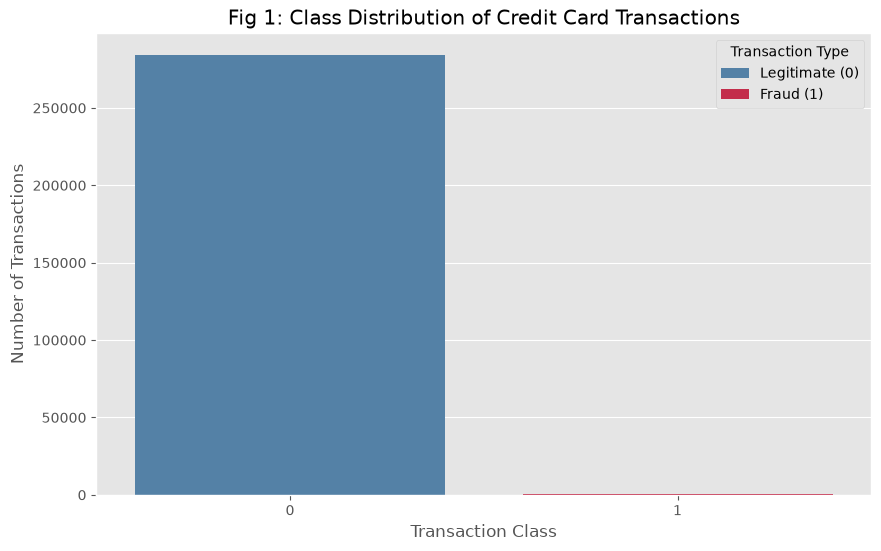

In [13]:
# Count plot (Bar chart) of the number of legitimate and fraudulent transactions

plt.figure(figsize=(10,6))
ax = sns.countplot(
    x='Class',
    hue='Class', 
    data=df, 
    palette=['steelblue', 'crimson']
)

plt.title("Fig 1: Class Distribution of Credit Card Transactions")
plt.xlabel('Transaction Class')
plt.ylabel('Number of Transactions')

# Rename the legend
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, ['Legitimate (0)', 'Fraud (1)'], title='Transaction Type')

#plt.legend(title='Class', loc='upper right', labels=['Legitimate (0)', 'Fraud (1)'])

#plt.yscale('log')

#plt.xticks([0,1], ['Legitimate (0)', 'Fraud (1)'])
#ax.set_xticklabels(['Legitimate (0)', 'Fraud (1)'])

plt.show()

**Figure 1. Class Distribution of Credit Card Transactions**

Figure 1: Bar chart showing the distribution of legitimate and fraudulent credit card transactions in the dataset. The x-axis represents the transaction class (Legitimate = 0, Fraud = 1), while the y-axis represents the number of transactions. Steel blue indicates legitimate transactions, while crimson represents fraudulent transactions.

### Class Distribution Interpretation

Figure 1 illustrates the distribution of legitimate and fraudulent credit card transactions in the dataset. Out of 284,807 transactions, 284,315 (99.83%) are legitimate, whereas only 492 (0.17%) are fraudulent. The overwhelming dominance of legitimate transactions causes the fraud class to appear as a very small bar in the count plot.

This visualization clearly demonstrates the severe class imbalance present in the dataset. Such an imbalance may cause a machine learning model to favour the majority class during prediction, making fraudulent transactions more difficult to identify.

## 2.2: Percentage of Fraud vs. Non-Fraud

In [14]:
# Calculate the percentage of each transaction class

class_percentage = (df['Class'].value_counts(normalize=True) * 100).round(3)
print(class_percentage)

Class
0    99.827
1     0.173
Name: proportion, dtype: float64


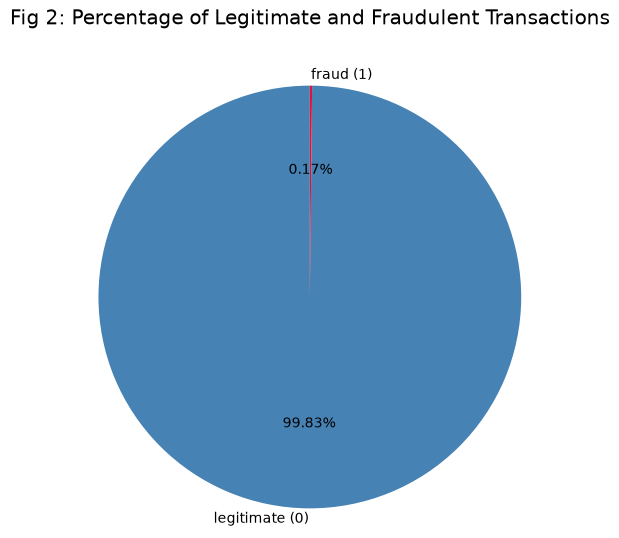

In [15]:
# Plot the percentage of each transaction class

plt.figure(figsize=(6,6))

plt.pie(
    class_percentage,
    labels= ['legitimate (0)', 'fraud (1)'],
    autopct='%1.2f%%',
    colors=['steelblue','crimson'],
    startangle=90,
    labeldistance=1.05
)
plt.title("Fig 2: Percentage of Legitimate and Fraudulent Transactions",pad=30)
plt.axis('equal') 
plt.show()

**Figure 2. Percentage of Legitimate and Fraudulent Transactions.**
 
Pie chart showing the proportion of transaction classes in the dataset. The steel blue slice represents legitimate transactions (Class = 0) accounting for 99.83% of all transactions, while the crimson red slice represents fraudulent transactions (Class = 1) accounting for 0.17%. The chart highlights the severe class imbalance in the dataset.

### Percentage of Legitimate and Fraudulent Transactions Interpretation

Figure 2 presents the percentage distribution of legitimate and fraudulent credit card transactions. Legitimate transactions account for 99.83% of the dataset, while fraudulent transactions constitute only 0.17%. This demonstrates that fraudulent activities occur extremely infrequently compared to legitimate transactions.

Unlike the previous count plot, which emphasizes the difference in the number of transactions, the pie chart highlights the relative proportion of each class. Together, these visualizations provide a clearer understanding of the extent of the class imbalance present in the dataset.

## 2.3: Correlation heatmap

In [16]:
# Calculate the correlation matrix

correlation_matrix = df.corr()


# Display the first five rows

correlation_matrix.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
Time,1.000000,1.173963e-01,-1.059333e-02,-4.196182e-01,-1.052602e-01,1.730721e-01,-6.301647e-02,8.471437e-02,-3.694943e-02,-8.660434e-03,...,4.473573e-02,1.440591e-01,5.114236e-02,-1.618187e-02,-2.330828e-01,-4.140710e-02,-5.134591e-03,-9.412688e-03,-0.010596,-0.012323
V1,0.117396,1.000000e+00,4.135835e-16,-1.227819e-15,-9.215150e-16,1.812612e-17,-6.506567e-16,-1.005191e-15,-2.433822e-16,-1.513678e-16,...,-2.457409e-16,-4.290944e-16,6.168652e-16,-4.425156e-17,-9.605737e-16,-1.581290e-17,1.198124e-16,2.083082e-15,-0.227709,-0.101347
V2,-0.010593,4.135835e-16,1.000000e+00,3.243764e-16,-1.121065e-15,5.157519e-16,2.787346e-16,2.055934e-16,-5.377041e-17,1.978488e-17,...,-8.480447e-17,1.526333e-16,1.634231e-16,1.247925e-17,-4.478846e-16,2.057310e-16,-4.966953e-16,-5.093836e-16,-0.531409,0.091289
V3,-0.419618,-1.227819e-15,3.243764e-16,1.000000e+00,4.711293e-16,-6.539009e-17,1.627627e-15,4.895305e-16,-1.268779e-15,5.568367e-16,...,5.706192e-17,-1.133902e-15,-4.983035e-16,2.686834e-19,-1.104734e-15,-1.238062e-16,1.045747e-15,9.775546e-16,-0.210880,-0.192961
V4,-0.105260,-9.215150e-16,-1.121065e-15,4.711293e-16,1.000000e+00,-1.719944e-15,-7.491959e-16,-4.104503e-16,5.697192e-16,6.923247e-16,...,-1.949553e-16,-6.276051e-17,9.164206e-17,1.584638e-16,6.070716e-16,-4.247268e-16,3.977061e-17,-2.761403e-18,0.098732,0.133447


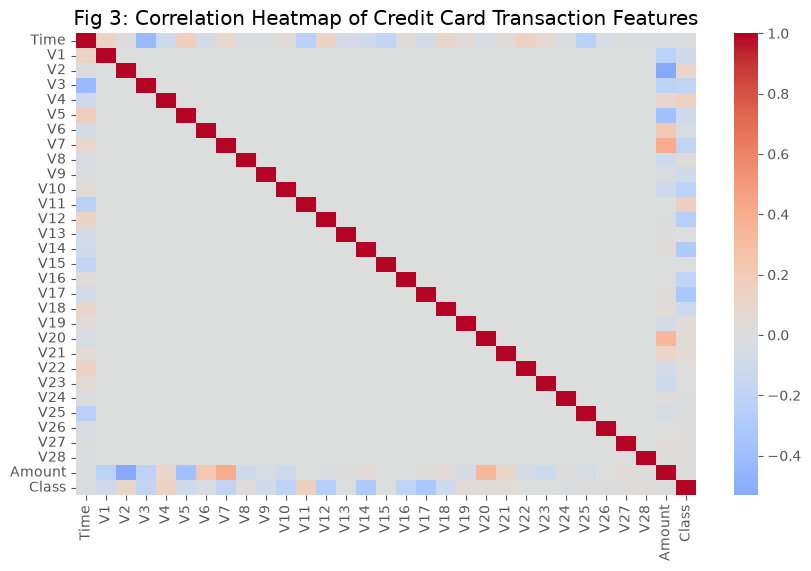

In [17]:
# plot the correlation matrix as a heatmap

plt.figure(figsize=(10,6))

sns.heatmap(
    correlation_matrix,
    cmap='coolwarm',
    center = 0
)
plt.title('Fig 3: Correlation Heatmap of Credit Card Transaction Features')
plt.show()

**Figure 3: Correlation Heatmap of Credit Card Transaction Features**

- X-axis: Credit card transaction variables (Time, V1–V28, Amount, Class).
- Y-axis: Credit card transaction variables (Time, V1–V28, Amount, Class).
- Colour scale:
  * 🔴 Red = Positive correlation (+1)
  * ⚪ Grey = Little or no correlation (0)
  * 🔵 Blue = Negative correlation (−1)
- Diagonal cells: Perfect correlation of each variable with itself (correlation = 1.0).

### Correlation Heatmap of Credit Card Transaction Features Interpretation

Figure 3 presents the correlation between all numerical variables in the credit card fraud dataset. The strong red diagonal represents a perfect correlation (correlation coefficient = 1.0), as each variable is perfectly correlated with itself. Most of the remaining cells are grey, indicating that the majority of variables have little or no linear relationship with one another. This is expected because the features V1–V28 were generated using Principal Component Analysis (PCA), which transforms the original variables into components that are largely uncorrelated.

Small regions of blue and red are observed around the Amount and Class variables, indicating that some features have weak to moderate positive or negative correlations with transaction amount and fraud status. Although these relationships are generally not strong, they suggest that certain variables may provide useful information for distinguishing fraudulent transactions from legitimate ones. Overall, the heatmap indicates that multicollinearity among the PCA-transformed features is minimal, which is advantageous for many machine learning algorithms and supports the use of these features for fraud detection.

## 2.4 Amount Distribution

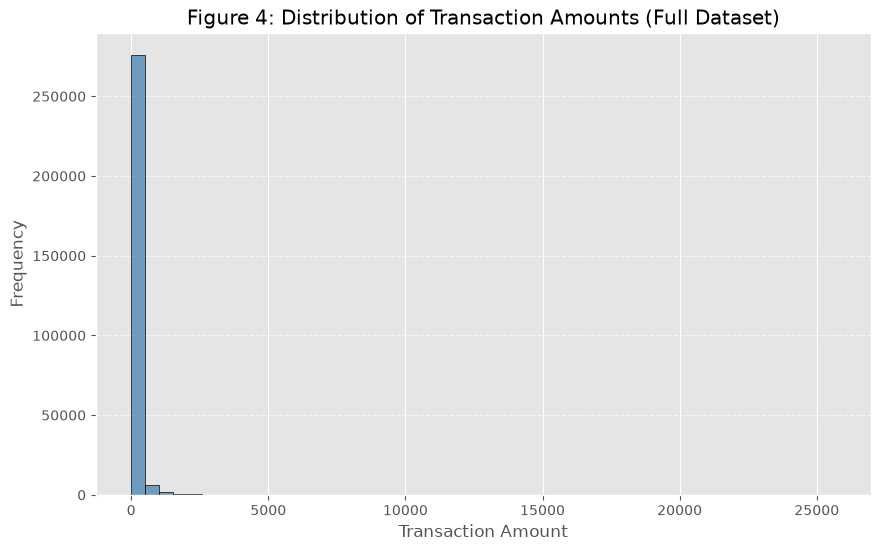

In [18]:
# Plot the distribution of the 'Amount' feature

plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x='Amount',
    bins=50,
    color='steelblue',
    edgecolor='black',
)
plt.title('Figure 4: Distribution of Transaction Amounts (Full Dataset)')
plt.xlabel('Transaction Amount')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

**Figure 4: Distribution of Transaction Amounts (Full Dataset)**

- Chart Type: Histogram
- X-axis: Transaction Amount
- Y-axis: Frequency (Number of Transactions)
- Bar Colour: Steel Blue
- Bar Border: Black
- Gridlines: Horizontal dashed gridlines to improve readability.
- Bins: 50 equal-width intervals used to group transaction amounts.

### Interpretation (Full Dataset)

Figure 4 presents the distribution of transaction amounts across the entire dataset. The histogram shows a highly right-skewed distribution, where most transactions involve relatively small amounts, while only a small number of transactions have very large values. These high-value transactions extend the distribution toward the right, producing a long right tail. This indicates the presence of outliers and considerable variability in transaction amounts.

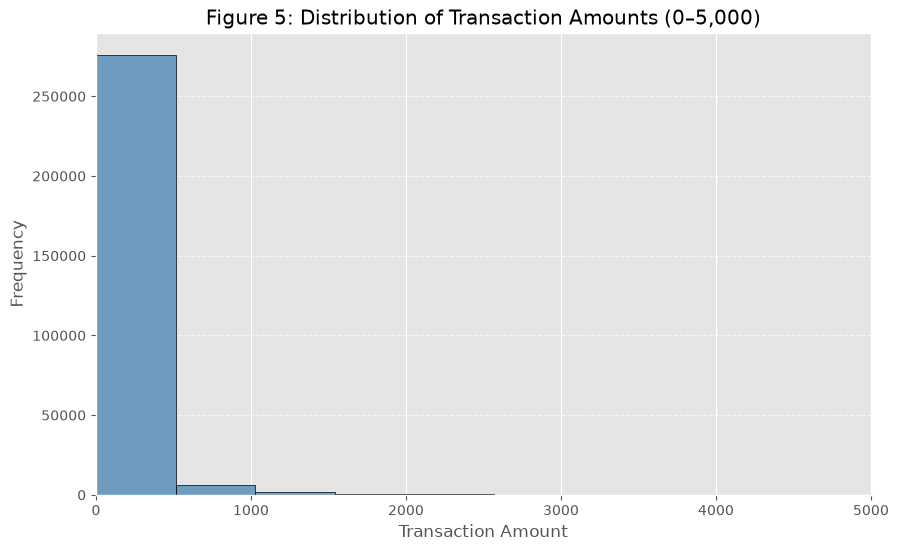

In [19]:
# Plot the distribution of the majority of the 'Amount' feature

plt.figure(figsize=(10, 6))
sns.histplot(
    data=df,
    x='Amount',
    bins=50,
    color='steelblue', 
    edgecolor='black',
)
plt.xlim(left=0, right=5000)  # Limit x-axis to focus on the majority of transactions
plt.title('Figure 5: Distribution of Transaction Amounts (0–5,000)')
plt.xlabel('Transaction Amount')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

**Distribution of the Majority of Transaction Amounts (0–5000)**

- Chart Type: Histogram
- X-axis: Transaction Amount (Limited to 0–5000)
- Y-axis: Frequency (Number of Transactions)
- Bar Colour: Steel Blue
- Bar Border: Black
- Gridlines: Horizontal dashed gridlines.
- Bins: 50 equal-width intervals.

### Distribution of (0–5000) Transaction Amounts Interpretation 

Figure 5 provides a closer view of the majority of transaction amounts by limiting the x-axis to ₍0–5000₎. This zoomed-in view reveals that the overwhelming majority of transactions occur within the lower amount range, while the extremely large transactions observed in the full dataset are excluded from the visualization. The distribution remains positively skewed, confirming that smaller transaction amounts dominate the dataset.

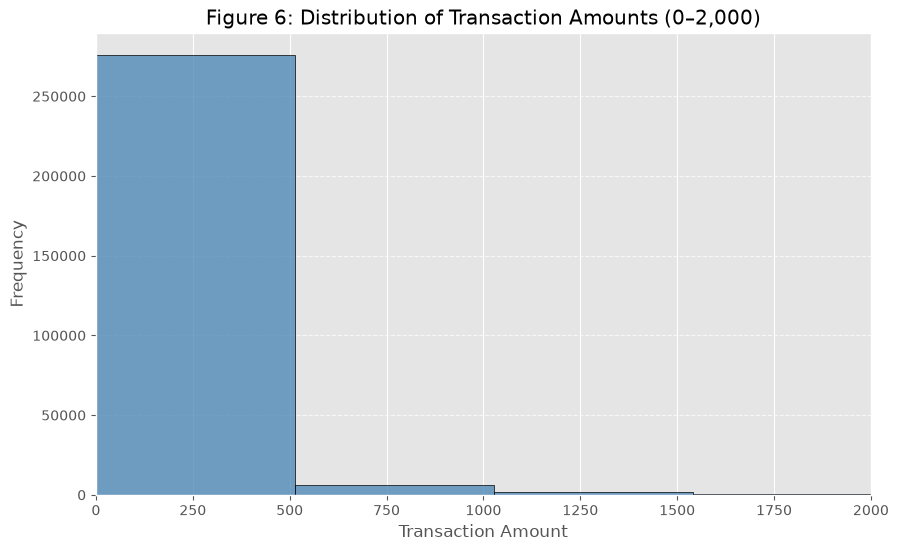

In [20]:
# Plot the distribution of the Close-up view of the 'Amount' feature

plt.figure(figsize=(10, 6))
sns.histplot(
    data=df,
    x='Amount',
    bins=50,
    color='steelblue', 
    edgecolor='black',
)
plt.xlim(left=0, right=2000)  # Limit x-axis to focus on the Close-up view of transactions
plt.title('Figure 6: Distribution of Transaction Amounts (0–2,000)')
plt.xlabel('Transaction Amount')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

**Figure 6: Distribution of the Close_up View of Transaction Amounts (0–2000)**

- Chart Type: Histogram
- X-axis: Transaction Amount (Limited to 0–2000)
- Y-axis: Frequency (Number of Transactions)
- Bar Colour: Steel Blue
- Bar Border: Black
- Gridlines: Horizontal dashed gridlines.
- Bins: 50 equal-width intervals.

### Distribution of Transaction Amounts (0–2,000) Interpretation

Figure 6 further zooms into transaction amounts between ₍0–2000₎, allowing the distribution of the most common transactions to be observed more clearly. The histogram shows that transaction frequency is highest at relatively low amounts and decreases steadily as transaction values increase. This view demonstrates that the vast majority of credit card transactions involve comparatively small amounts, whereas higher-value transactions occur much less frequently.

### Overall Interpretation of Transaction Amount Distribution

Figures 4–6 collectively show that transaction amounts in the credit card fraud dataset are highly right-skewed. The full distribution (Figure 4) reveals the presence of a small number of extremely high-value transactions that create a long right tail. By progressively restricting the x-axis to 0–5000 (Figure 5) and 0–2000 (Figure 6), the distribution of the majority of transactions becomes much clearer. These visualizations demonstrate that most credit card transactions involve relatively small amounts, while large transactions are comparatively rare. This pattern suggests the presence of outliers and indicates that the Amount feature may benefit from scaling before model training to improve model performance and ensure that large values do not disproportionately influence certain machine learning algorithms.

## 2.5. Time Distribution

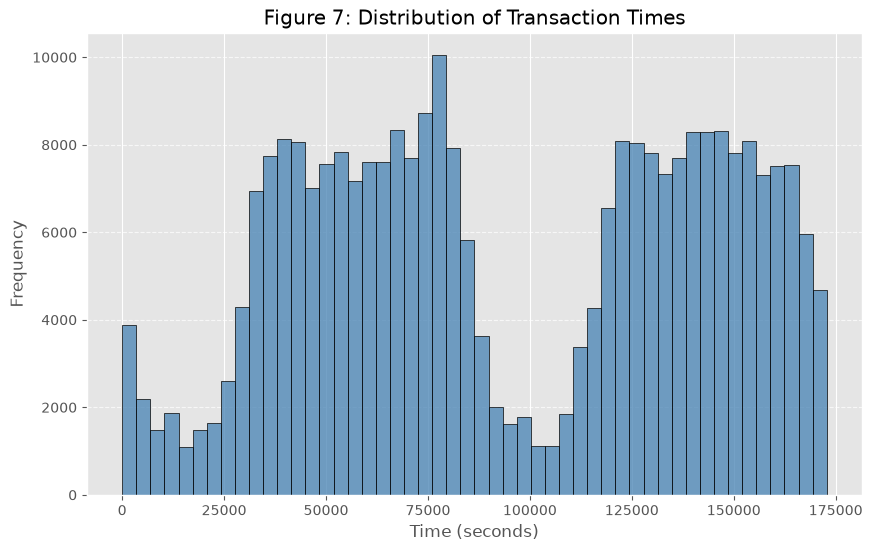

In [21]:
# Plot the distribution of the 'Time' feature

plt.figure(figsize=(10,6))

sns.histplot(data=df,
             x='Time',
             bins=50,
             color='steelblue',
             edgecolor='black'
             )

plt.title('Figure 7: Distribution of Transaction Times')
plt.xlabel('Time (seconds)')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

**Figure 7: Distribution of Transaction Times**

- X-axis: Transaction time (seconds) from the beginning of data collection.
- Y-axis: Frequency (number of transactions).
- Bars: Each bar represents the number of transactions that occurred within a particular time interval (bin).
- Colour: Steel blue bars represent transaction frequencies.
- Border: Black outlines distinguish individual histogram bins.
- Gridlines: Horizontal dashed gridlines improve readability of transaction frequencies.

## Figure 7 Interpretation

Figure 7 illustrates how credit card transactions are distributed throughout the observation period. Transactions occur continuously over approximately 172,792 seconds, with noticeable variations in activity across different time intervals. Several peaks indicate periods of high transaction activity, while valleys represent periods with fewer recorded transactions.

Unlike the Amount variable, which exhibits a highly right-skewed distribution, the Time variable does not show extreme skewness. Instead, it reflects changing transaction volumes over time, suggesting that customer activity is not constant throughout the recording period. This temporal variation may provide useful information for fraud detection models if fraudulent transactions tend to occur more frequently during particular periods.

## 2.6 Fraud vs. Non-Fraud Comparison for Selected Variables

### 2.6.1 Compare transaction amounts between legitimate and fraudulent transactions

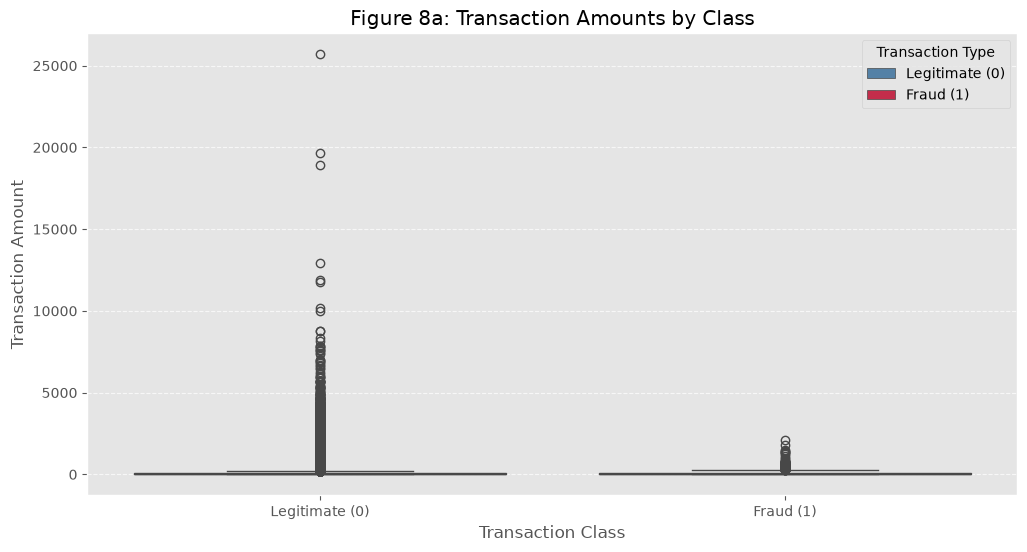

In [22]:
# Figure 8a: Distribution of transaction amounts by transaction class

plt.figure(figsize=(12, 6))

ax = sns.boxplot(
    data=df,
    x='Class',
    y='Amount',
    hue='Class',
    palette=['steelblue', 'crimson']
)

plt.title('Figure 8a: Transaction Amounts by Class')
plt.xlabel('Transaction Class')
plt.ylabel('Transaction Amount')

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, ['Legitimate (0)', 'Fraud (1)'], title='Transaction Type')

plt.xticks([0, 1], ['Legitimate (0)', 'Fraud (1)'])


plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()


**Figure 8: Transaction Amounts by Class**

- X-axis: Transaction Class (Legitimate and Fraud)
- Y-axis: Transaction Amount
- Blue Box: Legitimate transactions (Class = 0)
- Red Box: Fraudulent transactions (Class = 1)
- Horizontal line inside each box: Median transaction amount
- Box: Interquartile Range (IQR; middle 50% of the data)
- Whiskers: Typical range of transaction amounts
- Dots: Outlier transactions

## Figure 8a Interpretation: Transaction Amounts by Class

Figure 8 compares the distribution of transaction amounts for legitimate and fraudulent transactions using the complete dataset. Both classes contain numerous outliers, indicating that unusually large transactions occur in both legitimate and fraudulent activities. However, legitimate transactions exhibit a much wider spread and include substantially higher maximum transaction amounts than fraudulent transactions. The extreme outliers compress the central portions of the boxplots, making it difficult to clearly compare the typical transaction amounts between the two classes.

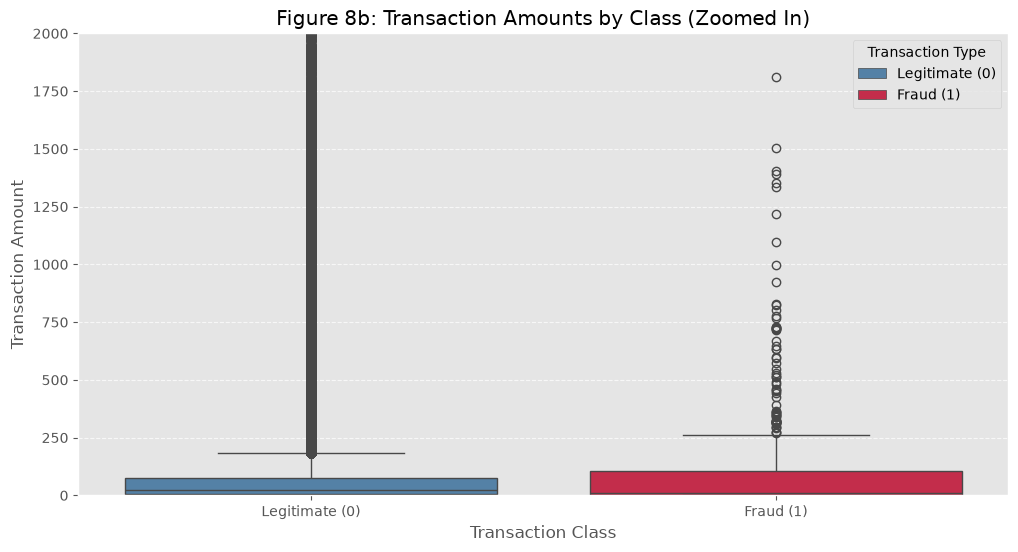

In [23]:
# Figure 8b: Zoomed-in view

plt.figure(figsize=(12, 6))

ax = sns.boxplot(
    data=df,
    x='Class',
    y='Amount',
    hue='Class',
    palette = ['steelblue', 'crimson']
)

plt.title('Figure 8b: Transaction Amounts by Class (Zoomed In)')
plt.xlabel('Transaction Class')
plt.ylabel('Transaction Amount')

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, ['Legitimate (0)', 'Fraud (1)'], title='Transaction Type')

plt.xticks([0, 1], ['Legitimate (0)', 'Fraud (1)'])


plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.ylim(0, 2000)  # Limit y-axis to focus on the majority of transaction amounts

plt.show()

**Figure 8b: Transaction Amounts by Class (Zoomed In)**

- X-axis: Transaction Class (Legitimate and Fraud)
- Y-axis: Transaction Amount (limited to 0–2000)
- Blue Box: Legitimate transactions (Class = 0)
- Red Box: Fraudulent transactions (Class = 1)
- Horizontal line inside each box: Median transaction amount
- Box: Interquartile Range (IQR; middle 50% of the data)
- Whiskers: Typical range of transaction amounts
- Dots: Outlier transactions within the displayed range

### Figure 8b Interpretation: Transaction Amounts by Class (Zoomed In)

Figure 9 presents a zoomed-in view of the transaction amount distributions by limiting the y-axis to the lower transaction values. This scaling reveals the central distributions that were compressed in Figure 8, making it easier to compare the typical transaction amounts of legitimate and fraudulent transactions. The plot shows that most transactions in both classes involve relatively small amounts, although fraudulent transactions tend to display a slightly higher median and greater variability within the displayed range. The zoomed view provides a clearer comparison of the majority of observations while still indicating the presence of outliers.

### 2.6.2 Compare Transaction Time by Class

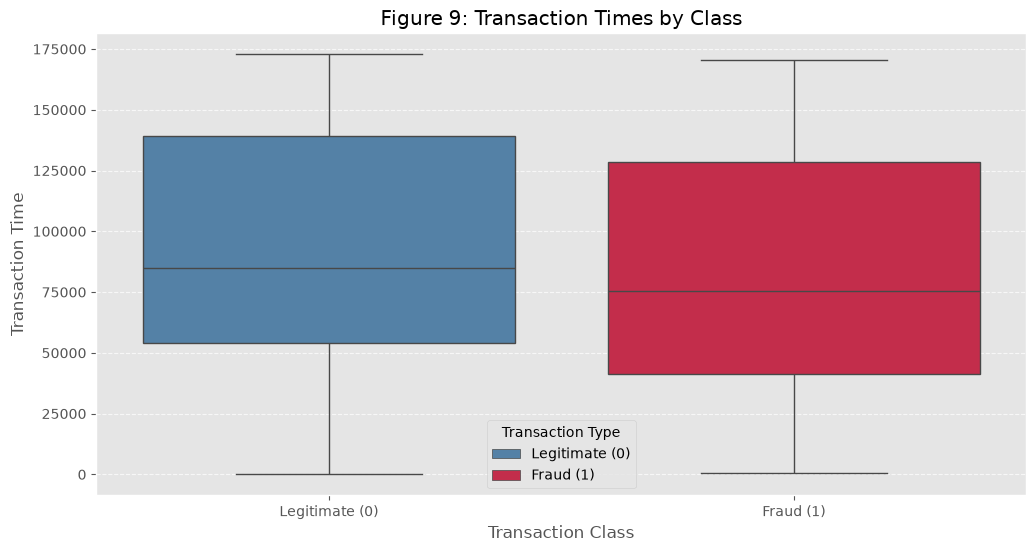

In [24]:
# Plot the distribution of the 'Time' feature

plt.figure(figsize=(12, 6))
ax = sns.boxplot(
     data=df,
     x='Class',
     y='Time', 
     hue='Class',
    palette = ['steelblue', 'crimson']
)
plt.title('Figure 9: Transaction Times by Class')
plt.xlabel('Transaction Class')
plt.ylabel('Transaction Time')

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, ['Legitimate (0)', 'Fraud (1)'], title='Transaction Type')

plt.xticks([0, 1], ['Legitimate (0)', 'Fraud (1)'])

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

**Figure 9: Transaction Times by Class.**

- X-axis: Transaction Class (Legitimate = 0, Fraud = 1).

- Y-axis: Transaction Time (seconds).

- Colours: Steel blue represents legitimate transactions, while crimson represents fraudulent transactions.

- Boxplot elements: The horizontal line inside each box represents the median transaction time, the box represents the interquartile range (IQR), the whiskers show the spread of the data (excluding outliers), and any points beyond the whiskers (if present) represent potential outliers.

### Figure 9: Transaction Times by Class Interpretation

Figure 9 compares the distribution of transaction times between legitimate and fraudulent transactions using boxplots. Both classes exhibit a broad spread of transaction times, with medians occurring around the middle of the observation period. The interquartile ranges and overall spreads are also similar, indicating that fraudulent transactions occur throughout the recording period rather than being concentrated at a specific time.

Overall, the figure suggests that transaction time alone does not clearly distinguish fraudulent transactions from legitimate ones. This implies that while the Time feature may contribute useful information when combined with other variables, it is unlikely to be a strong predictor of fraud on its own.

### 2.6.3 Compare V14 by Class

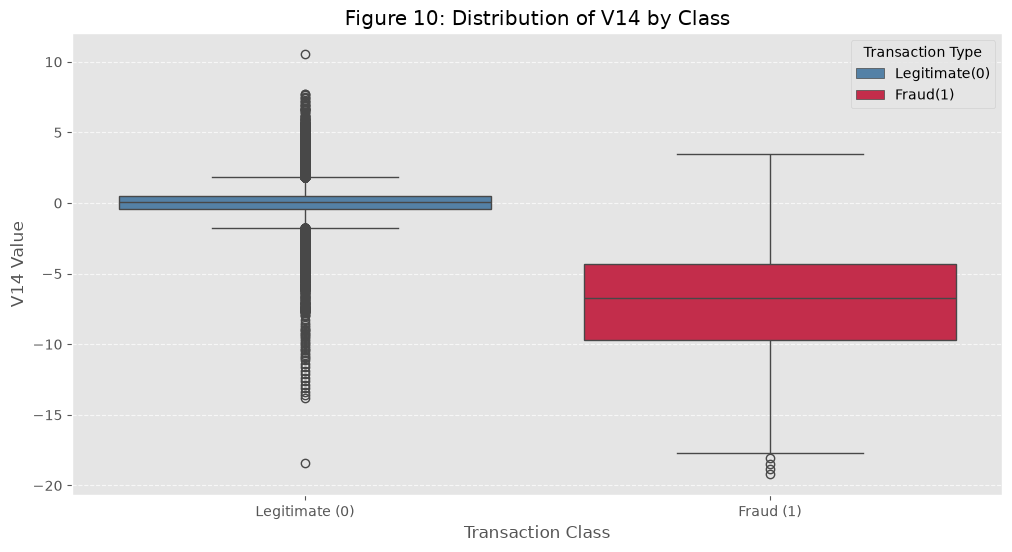

In [25]:
# Plot the V14 by Class

plt.figure(figsize=(12,6))

ax = sns.boxplot(
    data=df,
    x='Class',
    y='V14',
    hue='Class',
    palette = ['steelblue', 'crimson']
)
plt.title('Figure 10: Distribution of V14 by Class')
plt.xlabel('Transaction Class')
plt.ylabel('V14 Value')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.xticks([0, 1], ['Legitimate (0)', 'Fraud (1)'])
#plt.ylim(-5, 5)  # Limit y-axis to focus on the majority of V14 values

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, ['Legitimate(0)', 'Fraud(1)'], title= 'Transaction Type')
plt.show()

**Figure 10: Distribution of V14 by Class**

- X-axis: Transaction Class (Legitimate (0), Fraud (1))
- Y-axis: V14 feature values
- Blue box: Legitimate transactions (Class = 0)
- Red box: Fraudulent transactions (Class = 1)
- Box: Interquartile range (middle 50% of values)
- Horizontal line inside box: Median
- Whiskers: Typical range of observations
- Dots: Outliers

### Figure 10 Interpretation
Figure 10 (V14)

Figure 10 compares the distribution of V14 values between legitimate and fraudulent transactions. Legitimate transactions are centred around values close to zero, whereas fraudulent transactions have substantially lower (more negative) V14 values. The limited overlap between the two groups suggests that V14 is a strong feature for distinguishing fraudulent transactions from legitimate ones.

### 2.6.4 Compare V10 by Class

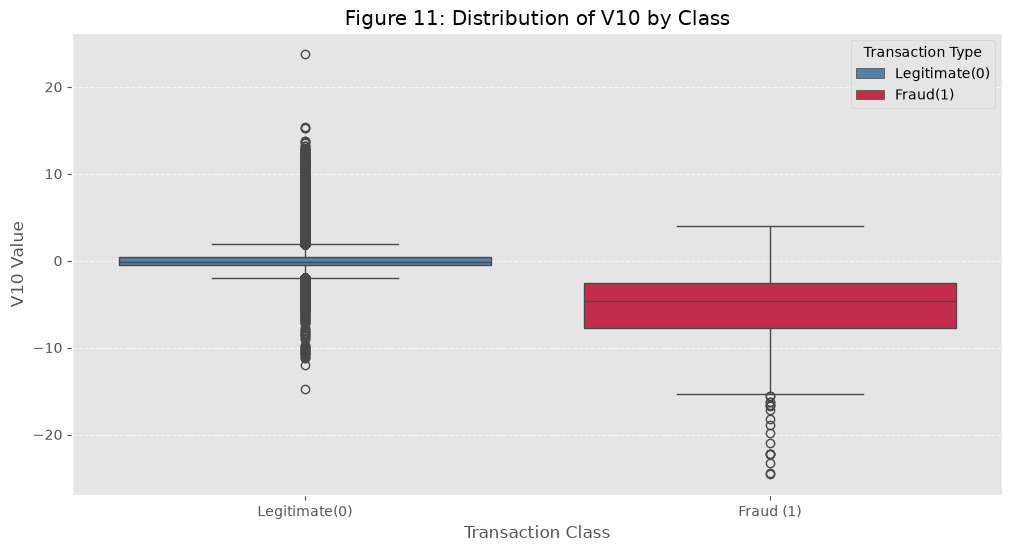

In [26]:
# Plot the distribution of the 'V10' feature

plt.figure(figsize=(12,6))

ax = sns.boxplot(
    data=df,
    x = 'Class',
    y='V10',
    hue= 'Class',
    palette=['steelblue', 'crimson']
)

plt.title('Figure 11: Distribution of V10 by Class')

plt.xlabel('Transaction Class')
plt.ylabel('V10 Value')

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.xticks([0,1], ['Legitimate(0)', 'Fraud (1)'])



handles, labels = ax.get_legend_handles_labels()
ax.legend(handles,['Legitimate(0)', 'Fraud(1)'], title= 'Transaction Type')

#plt.xlim()
plt.show()




**Figure 11: Distribution of V10 by Class**

- X-axis: Transaction Class (Legitimate (0), Fraud (1))
- Y-axis: V14 feature values
- Blue box: Legitimate transactions (Class = 0)
- Red box: Fraudulent transactions (Class = 1)
- Box: Interquartile range (middle 50% of values)
- Horizontal line inside box: Median
- Whiskers: Typical range of observations
- Dots: Outliers

### Figure 11 (V10) Interpretation

Figure 11 shows that V10 values for fraudulent transactions are generally much lower than those of legitimate transactions. Fraudulent observations have a noticeably different median and spread, indicating that V10 contains important discriminatory information that may improve fraud detection.

### 2.6.5 Compare V12 by Class

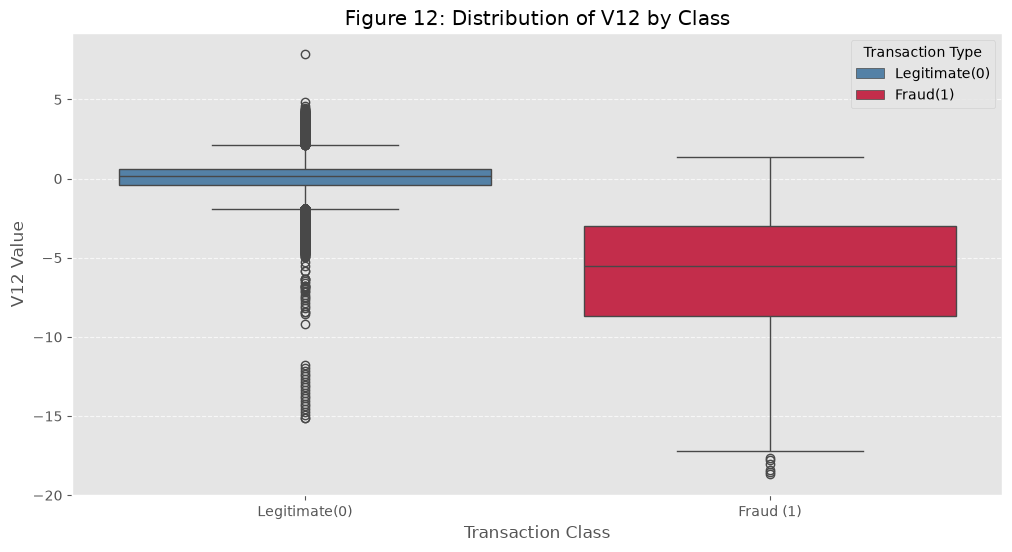

In [27]:
# Plot the distribution of the 'V12' feature

plt.figure(figsize=(12,6))

ax = sns.boxplot(
    data=df,
    x = 'Class',
    y='V12',
    hue= 'Class',
    palette=['steelblue', 'crimson']
)

plt.title('Figure 12: Distribution of V12 by Class')

plt.xlabel('Transaction Class')
plt.ylabel('V12 Value')

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.xticks([0,1], ['Legitimate(0)', 'Fraud (1)'])



handles, labels = ax.get_legend_handles_labels()
ax.legend(handles,['Legitimate(0)', 'Fraud(1)'], title= 'Transaction Type')

#plt.xlim()
plt.show()

**Figure 12: Distribution of V14 by Class**

- X-axis: Transaction Class (Legitimate (0), Fraud (1))
- Y-axis: V14 feature values
- Blue box: Legitimate transactions (Class = 0)
- Red box: Fraudulent transactions (Class = 1)
- Box: Interquartile range (middle 50% of values)
- Horizontal line inside box: Median
- Whiskers: Typical range of observations
- Dots: Outliers

### Figure 12 (V12) Interpretation

Figure 12 demonstrates a similar pattern for V12. Fraudulent transactions tend to have lower V12 values than legitimate transactions, with relatively little overlap between the two distributions. This indicates that V12 is also likely to be an informative predictor of fraudulent activity.

## 2.7 Relationship Between Variables

### 2.7.1 Amount vs Time (Scatter Plot)

c:\Users\User\anaconda3\envs\ml_env\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


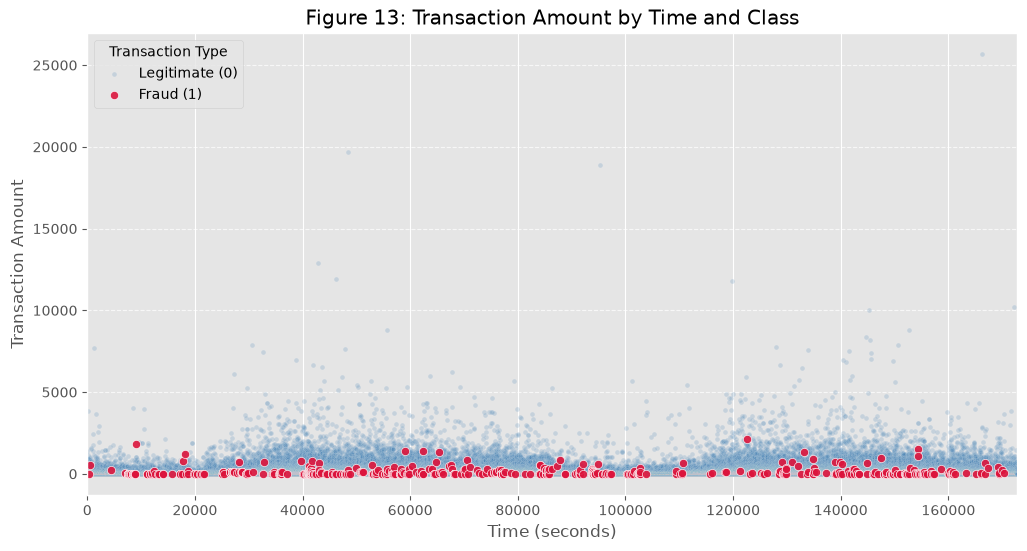

In [28]:
# Plot transaction amount against transaction time for legitimate and fraudulent transactions

plt.figure(figsize=(12,6))

# Plot legitimate transactions first
sns.scatterplot(
    data=df[df['Class']==0],
    x='Time',
    y='Amount',
    color='steelblue',
    alpha=0.20,
    s=12,
    label='Legitimate (0)'
)

# Plot fraud transactions on top
sns.scatterplot(
    data=df[df['Class']==1],
    x='Time',
    y='Amount',
    color='crimson',
    alpha=0.9,
    s=35,
    label='Fraud (1)'
)

plt.title('Figure 13: Transaction Amount by Time and Class')
plt.xlabel('Time (seconds)')
plt.ylabel('Transaction Amount')
plt.xlim(0,172800)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Transaction Type')
plt.show()

**Figure 13. Transaction Amount by Time and Class**

- X-axis: Transaction time (seconds from the first recorded transaction).
- Y-axis: Transaction amount.
- Blue points: Legitimate transactions (Class = 0).
- Red points: Fraudulent transactions (Class = 1).
- Each point: One credit card transaction.

### Figure Interpretation

Figure 13: Transaction Amount by Time and Class

Figure 13 illustrates the relationship between transaction time and transaction amount for legitimate and fraudulent transactions. Each point represents a single transaction, with legitimate transactions shown in steel blue and fraudulent transactions shown in crimson red. Most transactions involve relatively small amounts throughout the entire recording period, while a few high-value transactions appear as outliers. Fraudulent transactions are distributed across the full time range rather than being concentrated at specific times. 

Overall, the scatter plot does not reveal a clear relationship between transaction time and transaction amount, suggesting that time alone is unlikely to distinguish fraudulent from legitimate transactions.

### 2.7.2 Fraud Rate Across Transaction Amount Ranges

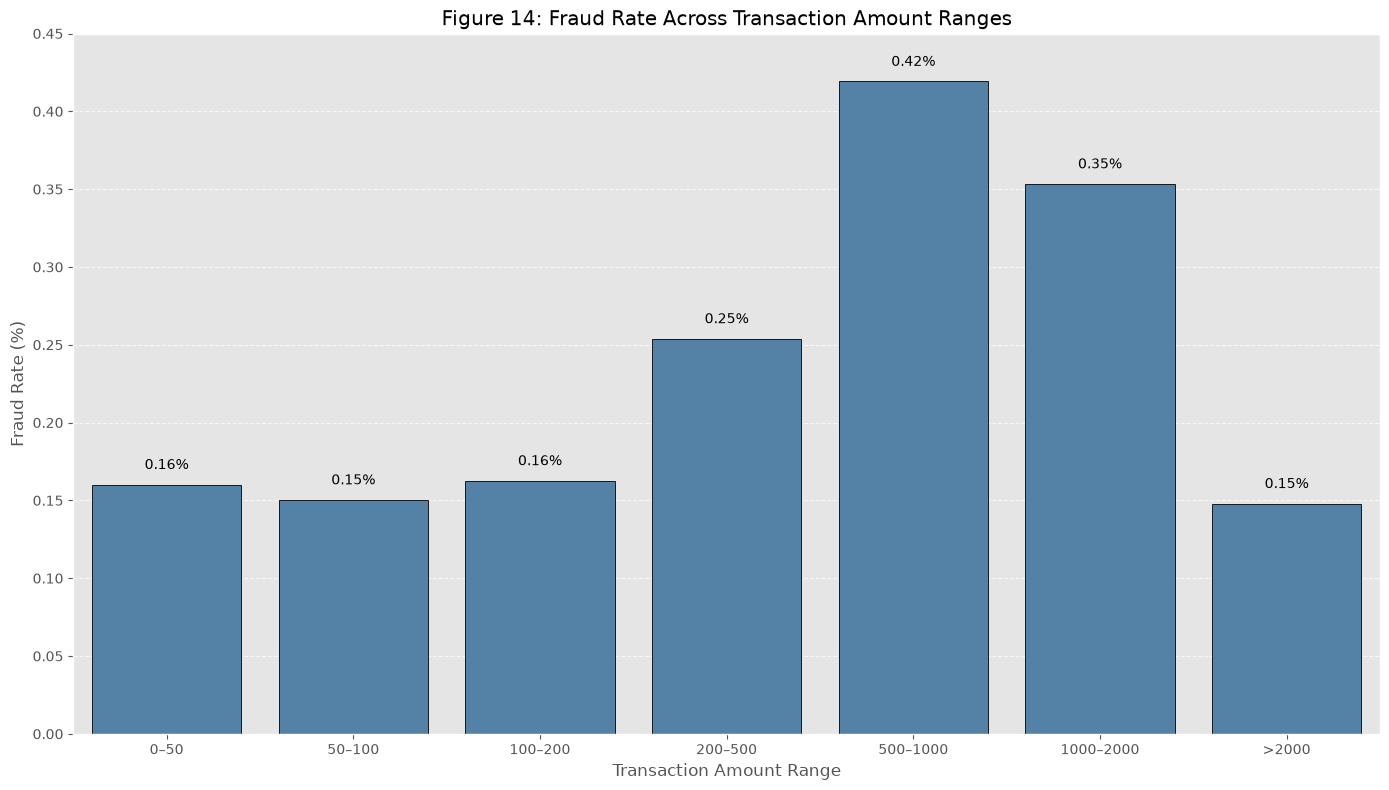

In [29]:
# Plot fraud rate across transaction amount ranges


plt.figure(figsize=(14,8))

bins = [0, 50, 100, 200, 500, 1000, 2000, df['Amount'].max()]

labels = [
    '0–50',
    '50–100',
    '100–200',
    '200–500',
    '500–1000',
    '1000–2000',
    '>2000'
]

df['Amount_Bin'] = pd.cut(
    df['Amount'],
    bins=bins,
    labels=labels,
    include_lowest=True
)

group_by_amount = (
    df.groupby('Amount_Bin')['Class'] # group amount_bin and select class
      .mean() # gives proportion of 1
      .mul(100) # convert proportion of 1 to %
      .reset_index()
)

ax = sns.barplot(
    data=group_by_amount,
    x='Amount_Bin',
    y='Class',
    color='steelblue',
    edgecolor='black',
    linewidth=0.6
)
for bar in ax.patches:
     bar.set_edgecolor('black')

for index, row in group_by_amount.iterrows():

    plt.text(
        index,
        row['Class'] + 0.01,
        f"{row['Class']:.2f}%",
        ha='center'
    )

plt.title('Figure 14: Fraud Rate Across Transaction Amount Ranges')

plt.xlabel('Transaction Amount Range')

plt.ylabel('Fraud Rate (%)')

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.ylim(0, 0.45)

plt.tight_layout()

plt.show()

In [30]:
group_by_amount

,Amount_Bin,Class
0,0–50,0.160172
1,50–100,0.150319
2,100–200,0.162625
3,200–500,0.253872
4,500–1000,0.419220
5,1000–2000,0.353357
6,>2000,0.147929


**Figure 14: Fraud rate across predefined transaction amount ranges.** 

Transaction amounts were grouped into seven categories (0–50, 50–100, 100–200, 200–500, 500–1000, 1000–2000, and >2000), and the percentage of fraudulent transactions within each category was calculated and displayed as a bar chart.

### Figure 14 Interpretation

Figure 14 shows that the likelihood of fraud varies across transaction amount ranges. Transactions between 500 and 1000 exhibited the highest fraud rate (approximately 0.42%), followed by transactions between 1000 and 2000 (approximately 0.35%). Lower-value transactions (0–200) had comparatively lower fraud rates of about 0.15–0.16%, while transactions above 2000 also showed a relatively low fraud rate (approximately 0.15%). These findings suggest that fraudulent activity in this dataset is relatively more concentrated in medium-to-high transaction amounts rather than in very small or extremely large transactions.

# Machine Learning Preparation

# Step 3 — Train-Test Split

After completing the exploratory analysis, the dataset was divided into training and testing subsets. A stratified 80/20 split was used so that the proportion of legitimate and fraudulent transactions was approximately maintained in both subsets.

Stratification is particularly important for this dataset because fraudulent transactions represent only a very small proportion of all observations. Without stratification, random splitting could produce slightly different class proportions between the training and testing sets.

In [31]:
# Separate features and target variable

X, y = split_features_and_target(df)


print("Features shape:", X.shape)
print("Target shape:", y.shape)


# Split the dataset into training and testing sets

X_train, X_test, y_train, y_test = split_data(X, y)


# Verify the shapes of the training and testing sets

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

print("Training labels:", y_train.shape)
print("Testing labels:", y_test.shape)


# Display the class distribution in the original, training, and testing datasets
print("Original Dataset")
print(y.value_counts(normalize=True) * 100)

print("\nTraining Dataset")
print(y_train.value_counts(normalize=True) * 100)

print("\nTesting Dataset")
print(y_test.value_counts(normalize=True) * 100)

Features shape: (284807, 30)
Target shape: (284807,)
Training set shape: (227845, 30)
Testing set shape: (56962, 30)
Training labels: (227845,)
Testing labels: (56962,)
Original Dataset
Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64

Training Dataset
Class
0    99.827075
1     0.172925
Name: proportion, dtype: float64

Testing Dataset
Class
0    99.827955
1     0.172045
Name: proportion, dtype: float64


### Interpretation

The dataset was successfully divided into training and testing sets using an 80/20 stratified split. The training set contains 227,845 observations, while the testing set contains 56,962 observations.

The class proportions remain highly similar across the original, training, and testing datasets. The training set contains approximately 99.83% legitimate transactions and 0.17% fraudulent transactions, while the testing set contains approximately 99.83% legitimate transactions and 0.17% fraudulent transactions.

This demonstrates that stratification successfully preserved the original class distribution across both subsets. Importantly, the testing set remains completely separate from the training data and will be reserved for evaluating the final model.

## 4. Feature Scaling

The `Time` and `Amount` features have different numerical scales and units. To prevent features with larger numerical values from disproportionately influencing models that are sensitive to feature scale, StandardScaler was applied to these two features.

The scaler was fitted using only the training data. The learned mean and standard deviation were then used to transform both the training and testing sets. This ensures that information from the testing set is not used during preprocessing and helps prevent data leakage.

The anonymized PCA-derived features (`V1`–`V28`) were not scaled because they are already standardized as part of the original dataset transformation.

In [32]:

# Apply StandardScaler to Time and Amount

X_train, X_test, scaler = scale_features(
    X_train,
    X_test
)

# Check the scaled training features

print("Scaled training features:")
print(X_train[["Time", "Amount"]].describe())

Scaled training features:
               Time        Amount
count  2.278450e+05  2.278450e+05
mean  -1.409578e-16  3.742243e-17
std    1.000002e+00  1.000002e+00
min   -1.998073e+00 -3.516894e-01
25%   -8.561495e-01 -3.291944e-01
50%   -2.122647e-01 -2.639429e-01
75%    9.366285e-01 -4.262209e-02
max    1.640549e+00  1.021170e+02


### Interpretation

The `Time` and `Amount` features were successfully standardized. After transformation, both features had means effectively equal to zero and standard deviations approximately equal to one in the training set. This confirms that `StandardScaler` successfully transformed the two variables to a common standardized scale.

The scaler was fitted exclusively on the training data, with the learned parameters subsequently used to transform both the training and testing sets. This approach prevents information from the testing set from influencing the preprocessing stage and therefore helps prevent data leakage.

The maximum standardized value for `Amount` was approximately 102.12, indicating the presence of transactions substantially larger than the typical transaction amount. Standardization changes the scale of the feature but does not remove these observations.

# Step 5 Address Class Imbalance

The dataset is highly imbalanced, with fraudulent transactions representing only a very small proportion of the total observations. The original training set contains 227,451 legitimate transactions and only 394 fraudulent transactions.

This imbalance can cause a machine learning model to favor the majority class and potentially perform poorly when identifying fraudulent transactions.

To address this issue, two sampling techniques were considered:

1. Random Undersampling
2. Synthetic Minority Oversampling Technique (SMOTE)

Both techniques were applied **only to the training data**. The testing data was left unchanged to preserve an unbiased evaluation of model performance.

### Step 5.1: Import Sampling Functions

In [33]:
# Establish the Baseline with Original Training Class Distribution

print("Original Training Class Distribution:")
print(y_train.value_counts())

print("\nOriginal Training Class Distribution (%):")
print(y_train.value_counts(normalize=True) * 100)

Original Training Class Distribution:
Class
0    227451
1       394
Name: count, dtype: int64

Original Training Class Distribution (%):
Class
0    99.827075
1     0.172925
Name: proportion, dtype: float64


### Interpretation

The training data is severely imbalanced. Approximately 99.83% of the training transactions are legitimate, while only about 0.17% are fraudulent.

This imbalance means that a model could achieve a very high overall accuracy by predominantly predicting the majority class while still failing to identify fraudulent transactions effectively. Therefore, an imbalance-handling strategy is required before model training.

### Step 5.2  Random Undersampling

In [34]:
# Apply random undersampling to the training data

X_under, y_under = random_undersample(
    X_train,
    y_train
)


#check the results of random undersampling

print("After Random Undersampling:")
print(y_under.value_counts())

print("\nAfter Random Undersampling (%):")
print(y_under.value_counts(normalize=True) * 100)

print("\nDataset size comparison:")
print("Original training set:", len(y_train))
print("Undersampled training set:", len(y_under))

After Random Undersampling:
Class
0    788
1    394
Name: count, dtype: int64

After Random Undersampling (%):
Class
0    66.666667
1    33.333333
Name: proportion, dtype: float64

Dataset size comparison:
Original training set: 227845
Undersampled training set: 1182


### Interpretation

Random undersampling reduced the majority class from 227,451 legitimate transactions to 788 while retaining all 394 fraudulent transactions. This produced a training set of 1,182 observations, with approximately 66.67% legitimate transactions and 33.33% fraudulent transactions.

The major advantage of undersampling is that it substantially reduces the size of the training dataset, which can make model training faster and computationally less expensive.

However, the technique removes a very large proportion of legitimate transactions. Consequently, potentially useful information about legitimate transaction patterns may be lost. This information loss is an important trade-off when using random undersampling for a highly imbalanced dataset.

### Step 5.3  SMOTE

In [35]:
# Apply SMOTE to the training data

X_smote, y_smote = apply_smote(
    X_train,
    y_train
)


# Verify the result

print("After SMOTE:")
print(y_smote.value_counts())

print("\nAfter SMOTE (%):")
print(y_smote.value_counts(normalize=True) * 100)

print("\nDataset size comparison:")
print("Original training set:", len(y_train))
print("SMOTE training set:", len(y_smote))

After SMOTE:
Class
0    227451
1    113725
Name: count, dtype: int64

After SMOTE (%):
Class
0    66.666764
1    33.333236
Name: proportion, dtype: float64

Dataset size comparison:
Original training set: 227845
SMOTE training set: 341176


### Interpretation

SMOTE increased the minority class from 394 fraudulent transactions to 113,725 synthetic fraudulent observations while retaining all 227,451 legitimate transactions. This produced a training set of 341,176 observations, with approximately 66.67% legitimate transactions and 33.33% fraudulent transactions.

Unlike random undersampling, SMOTE does not discard legitimate observations. Instead, it generates synthetic minority-class observations based on existing minority samples.

The major advantage is that more of the original training information is retained. However, SMOTE produces a substantially larger dataset and introduces synthetic observations. Because these observations are generated rather than directly observed transactions, they may not perfectly represent real-world fraudulent behavior.

### Comparison of Random Undersampling and SMOTE

| Aspect | Random Undersampling | SMOTE |
|---|---|---|
| Original training data | 227,845 | 227,845 |
| Legitimate transactions after sampling | 788 | 227,451 |
| Fraudulent transactions after sampling | 394 | 113,725 |
| Final training size | **1,182** | **341,176** |
| Removes legitimate data? | **Yes** | **No** |
| Creates synthetic fraud? | No | **Yes** |
| Main advantage | Smaller and faster training dataset | Preserves majority-class information |
| Main disadvantage | Massive information loss | Larger dataset and synthetic observations |

### Trade-off Between the Techniques

Random undersampling and SMOTE address class imbalance in different ways.

Random undersampling is computationally efficient because it dramatically reduces the number of majority-class observations. However, in this dataset, it discards 226,663 legitimate transactions, meaning that a large amount of potentially useful information is lost.

SMOTE takes the opposite approach. It retains all legitimate transactions and generates additional synthetic minority-class observations. This provides the model with substantially more training data and reduces the risk of losing legitimate transaction patterns. However, it increases the size of the dataset considerably and introduces synthetic observations that may not completely reflect real fraudulent transactions.

Therefore, the choice involves a trade-off between **information retention and computational efficiency**. Random undersampling prioritizes a smaller and faster dataset, whereas SMOTE prioritizes retaining the original majority-class information while increasing representation of the minority class.

# Phase 2 — Model Training & Selection

## Overview

The objective of this phase is to train, evaluate, and compare machine learning models for credit card fraud detection.

Three supervised classification models will be evaluated:

1. Logistic Regression — baseline model
2. Random Forest Classifier — nonlinear ensemble model
3. XGBoost Classifier — gradient boosting model

Because the dataset is highly imbalanced, model performance will not be judged by accuracy alone.

The models will be evaluated using:

- Confusion Matrix
- Precision
- Recall
- F1 Score
- ROC-AUC
- Precision-Recall Curve
- PR-AUC

Recall is particularly important because a false negative represents a fraudulent transaction that the system failed to identify.

## 2.1 Understand the Training Data — Class Distribution

Before training the models, the class distribution of the training dataset was examined.

This is important because credit card fraud detection involves a highly imbalanced classification problem, where fraudulent transactions represent only a very small proportion of all transactions.

The training data contains:

- **Class 0 (Legitimate): 227,451 transactions**
- **Class 1 (Fraudulent): 394 transactions**

Therefore, the dataset is highly imbalanced, with approximately **99.83% legitimate transactions** and only **0.17% fraudulent transactions**.

This severe class imbalance means that a model could achieve high overall accuracy while still performing poorly at detecting fraudulent transactions. Therefore, class-imbalance handling and fraud-focused evaluation metrics such as recall, precision, F1-score, ROC-AUC, and PR-AUC are required.

In [36]:
# Examine the class distribution in the training data

class_distribution = y_train.value_counts()
class_proportions = y_train.value_counts(normalize=True)

print("Training class distribution:")
print(class_distribution)

print("\nTraining class proportions:")
print(class_proportions)

print(f"\nLegitimate transactions (Class 0): {class_distribution[0]}")
print(f"Fraudulent transactions (Class 1): {class_distribution[1]}")

Training class distribution:
Class
0    227451
1       394
Name: count, dtype: int64

Training class proportions:
Class
0    0.998271
1    0.001729
Name: proportion, dtype: float64

Legitimate transactions (Class 0): 227451
Fraudulent transactions (Class 1): 394


## 2.2 Training Strategy

The dataset is severely imbalanced, with legitimate transactions greatly outnumbering fraudulent transactions.

To reduce the tendency of the models to favor the majority class, class-imbalance handling was incorporated into the training process.

The following strategies were used:

- **Logistic Regression:** `class_weight="balanced"`
- **Random Forest:** `class_weight="balanced"`
- **XGBoost:** `scale_pos_weight`, calculated from the ratio of legitimate to fraudulent transactions in the training set.

This allows the models to give greater importance to fraudulent transactions during training.

Three models were then trained and evaluated:

1. Logistic Regression
2. Random Forest
3. XGBoost

# 2.3 Train Model 1 — Logistic Regression

Logistic Regression is used as the baseline classification model for this fraud-detection task.

Because the dataset is highly imbalanced, class weighting is used to give greater importance to the minority fraud class.

### Step 1 — Create and Train the Model — Logistic Regression

The Logistic Regression model is trained using the training dataset. class_weight='balanced' is used to give greater weight to the minority fraud class because fraudulent transactions are highly underrepresented in the dataset.

In [37]:
# Train Logistic Regression using the reusable team function

logistic_model = train_logistic_regression(
    X_train,
    y_train
)

# Display the trained model
logistic_model

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default 

### Step 2 — Generate Predictions and Probabilities — Logistic Regression

After training, the model is used to predict the fraud class for transactions in the test set and probabilities obtained, which are used for ROC-AUC and Precision–Recall analysis..

In [38]:
# Evaluate Logistic Regression using the reusable evaluation function

logistic_metrics, y_pred_logistic, y_prob_logistic = evaluate_model(
    logistic_model,
    X_test,
    y_test,
    "Logistic Regression"
)

print("Prediction shape:", y_pred_logistic.shape)
print("Probability shape:", y_prob_logistic.shape)


Prediction shape: (56962,)
Probability shape: (56962,)


### Step 3 — Confusion Matrix — Logistic Regression

The confusion matrix shows how the Logistic Regression model classified legitimate and fraudulent transactions.

In [39]:

# Generate confusion matrix using the reusable evaluation function

cm_logistic = get_confusion_matrix(
    y_test,
    y_pred_logistic
)

print("Confusion Matrix for Logistic Regression:")
print(cm_logistic)

Confusion Matrix for Logistic Regression:
[[55478  1386]
 [    8    90]]


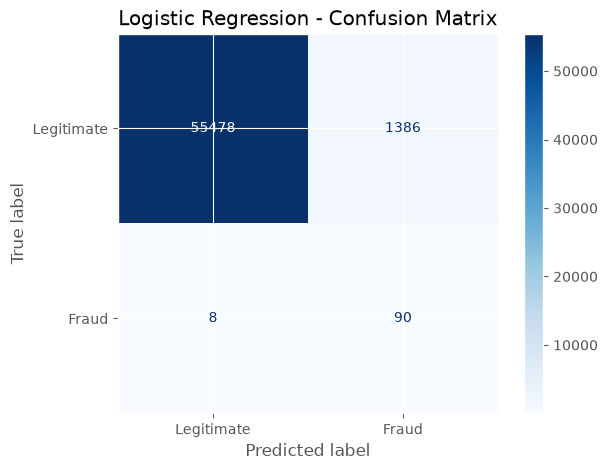

In [40]:
# Actual plotted confusion matrix

plot_confusion_matrix(
    y_test,
    y_pred_logistic,
    "Logistic Regression"
)

#### Confusion Matrix Interpretation

The model correctly identified **55,478 legitimate transactions** and **90 fraudulent transactions**.

However, **1,386 legitimate transactions were incorrectly classified as fraudulent**, producing false-positive alerts. The model also missed **8 fraudulent transactions**.

Therefore, the model demonstrates strong fraud detection sensitivity but produces a relatively large number of false-positive predictions.

#### Evaluation Metrics — Logistic Regression

Because fraud detection is a highly imbalanced classification problem, precision, recall, and F1-score are evaluated rather than relying on accuracy alone.

### Step 4 — Precision, Recall and F1-Score — Logistic Regression 

Precision measures the proportion of transactions predicted as fraudulent that were actually fraudulent. Recall measures the proportion of actual fraudulent transactions that were correctly detected, while F1-score provides a balance between precision and recall.

In [41]:
print("Evaluation Metrics for Logistic Regression:")

print(
    f"Precision: {logistic_metrics['Precision']:.4f} "
    f"→ {logistic_metrics['Precision']:.2%}"
)

print(
    f"Recall:    {logistic_metrics['Recall']:.4f} "
    f"→ {logistic_metrics['Recall']:.2%}"
)

print(
    f"F1-Score:  {logistic_metrics['F1 Score']:.4f} "
    f"→ {logistic_metrics['F1 Score']:.2%}"
)

Evaluation Metrics for Logistic Regression:
Precision: 0.0610 → 6.10%
Recall:    0.9184 → 91.84%
F1-Score:  0.1144 → 11.44%


### Step 5 — ROC-AUC — Logistic Regression

ROC-AUC measures the model's ability to distinguish between legitimate and fraudulent transactions across different classification thresholds.

In [42]:
print(
    f"ROC-AUC Score: {logistic_metrics['ROC-AUC']:.4f} "
    f"→ {logistic_metrics['ROC-AUC']:.2%}"
)

ROC-AUC Score: 0.9722 → 97.22%


### Step 6 — Precision-Recall Curve and PR-AUC — Logistic Regression

Because fraudulent transactions represent a very small proportion of the dataset, the Precision-Recall curve provides an important view of the model's performance, particularly its ability to identify fraud while controlling false-positive predictions.

### Step 6A — PR-AUC — Logistic Regression

In [43]:
print(
    f"PR-AUC: {logistic_metrics['PR-AUC']:.4f} "
    f"→ {logistic_metrics['PR-AUC']:.2%}"
)

PR-AUC: 0.7159 → 71.59%


### Step 6B — Precision–Recall Curve — Logistic Regression


This is where we use different variable names for the curve arrays so they do not overwrite the single-value precision and recall metrics.

Different variable names are used for the Precision–Recall curve arrays so they do not overwrite the single-value precision and recall metrics calculated earlier.

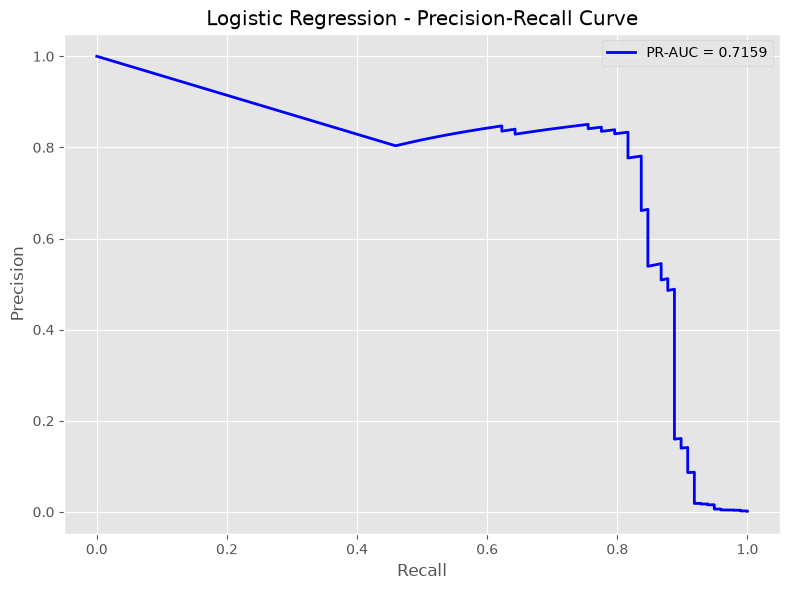

In [44]:
# Plot Precision-Recall Curve for Logistic Regression

plot_precision_recall_curve(
    y_test,
    y_prob_logistic,
    "Logistic Regression"
)

## Logistic Regression — Model Evaluation

| Metric | Result | Interpretation |
|---|---:|---|
| **Precision** | **6.10%** | Only about 6 out of every 100 transactions predicted as fraud were actually fraudulent. |
| **Recall** | **91.84%** | The model detected about 92% of the actual fraudulent transactions. |
| **F1-Score** | **11.44%** | The low score reflects the difficulty of balancing the model's very high recall with its very low precision. |
| **ROC-AUC** | **97.22%** | The model demonstrates strong ability to distinguish fraudulent transactions from legitimate transactions across classification thresholds. |
| **PR-AUC** | **71.59%** | This provides a more informative assessment of performance for the highly imbalanced fraud-detection problem. |

### Interpretation

The Logistic Regression model achieved a **high recall of 91.84%**, successfully identifying 90 of the 98 fraudulent transactions in the test set. This is important in fraud detection because missing fraudulent transactions can have significant consequences.

However, the model achieved a **precision of only 6.10%**, with 1,386 legitimate transactions incorrectly classified as fraudulent. This means the model generates a substantial number of false-positive alerts.

The **F1-score of 11.44%** reflects this imbalance between high recall and low precision. Meanwhile, the **ROC-AUC of 97.22%** indicates strong discriminatory ability, while the **PR-AUC of 71.59%** provides a more useful perspective given the severe class imbalance in the dataset.

Overall, Logistic Regression is a strong **baseline model** for this fraud-detection task, particularly because of its ability to detect fraudulent transactions. However, its large number of false positives limits its practical usefulness in its current form.

The next stage is therefore not simply to maximize accuracy, but to determine whether the model can achieve a better balance between **precision and recall** through threshold optimization and comparison with other machine-learning models.

### Logistic Regression — Conclusion

Logistic Regression provides a useful baseline for the fraud-detection task. The model achieves a high recall of 91.84%, successfully identifying most fraudulent transactions. However, its precision of only 6.10% indicates that the model produces a large number of false-positive alerts.

Although the ROC-AUC of 97.22% demonstrates strong overall discrimination, the PR-AUC of 71.59% shows that there is still considerable room for improvement when precision and recall are considered together in this highly imbalanced dataset.

Therefore, Logistic Regression establishes a strong recall-oriented baseline, but its low precision suggests that a more sophisticated model may provide a better balance between detecting fraud and reducing false-positive alerts.

# 2.4 Train Model 2 — Random Forest

Random Forest is used as the second classification model to capture nonlinear relationships between transaction features and fraudulent activity.

Because the dataset is highly imbalanced, `class_weight="balanced"` is used to give greater importance to the minority fraud class. The model uses 100 decision trees, with `random_state=42` used to ensure reproducibility.

### Step 1 — Create and Train the Model — Random Forest

In [45]:
# Train Random Forest using the reusable team function

random_forest_model = train_random_forest(
    X_train,
    y_train
)

#Display the trained model
random_forest_model

,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_fe

### Step 2 — Generate Predictions and Probabilities — Random Forest

After training, the Random Forest model is used to generate class predictions and predicted probabilities for the test set. The probability of the positive class represents the estimated probability that a transaction is fraudulent.

In [46]:
# Evaluate Random Forest using the reusable evaluation function

rf_metrics, y_pred_rf, y_prob_rf = evaluate_model(
    random_forest_model,
    X_test,
    y_test,
    "Random Forest"
)

print("Prediction shape:", y_pred_rf.shape)
print("Probability shape:", y_prob_rf.shape)

Prediction shape: (56962,)
Probability shape: (56962,)


### Step 3 — Confusion Matrix — Random Forest

The confusion matrix shows how the Random Forest model classified legitimate and fraudulent transactions, including correctly detected fraud cases and false-positive predictions.

In [47]:
cm_rf = get_confusion_matrix(
    y_test,
    y_pred_rf
)

print("Confusion Matrix for Random Forest:")
print(cm_rf)

Confusion Matrix for Random Forest:
[[56856     8]
 [   21    77]]


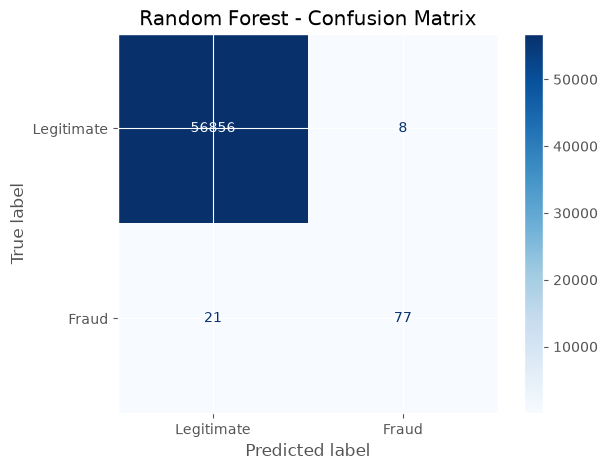

In [48]:
# Actual plotted confusion matrix

plot_confusion_matrix(
    y_test,
    y_pred_rf,
    "Random Forest"
)

### Step 4 — Precision, Recall and F1-Score — Random Forest

Precision, recall, and F1-score are used to evaluate the Random Forest model because accuracy alone is not appropriate for this highly imbalanced fraud-detection problem.

In [49]:
print("Evaluation Metrics for Random Forest:")

print(
    f"Precision: {rf_metrics['Precision']:.4f} "
    f"→ {rf_metrics['Precision']:.2%}"
)

print(
    f"Recall:    {rf_metrics['Recall']:.4f} "
    f"→ {rf_metrics['Recall']:.2%}"
)

print(
    f"F1-Score:  {rf_metrics['F1 Score']:.4f} "
    f"→ {rf_metrics['F1 Score']:.2%}"
)

Evaluation Metrics for Random Forest:
Precision: 0.9059 → 90.59%
Recall:    0.7857 → 78.57%
F1-Score:  0.8415 → 84.15%


### Step 5 — ROC-AUC — Random Forest

ROC-AUC measures the model's ability to distinguish fraudulent transactions from legitimate transactions across different classification thresholds.

In [50]:
print(
    f"ROC-AUC Score: {rf_metrics['ROC-AUC']:.4f} "
    f"→ {rf_metrics['ROC-AUC']:.2%}"
)

ROC-AUC Score: 0.9573 → 95.73%


### Step 6 — PR-AUC — Random Forest

Because the dataset contains very few fraudulent transactions compared with legitimate transactions, PR-AUC provides an important measure of the model's ability to balance precision and recall.

In [51]:
print(
    f"PR-AUC: {rf_metrics['PR-AUC']:.4f} "
    f"→ {rf_metrics['PR-AUC']:.2%}"
)

PR-AUC: 0.8629 → 86.29%


### Step 7 — Random Forest Feature Importance — Random Forest

Random Forest provides feature-importance scores that indicate the relative contribution of each feature to the model's decision-making process.

The features are ranked from most important to least important, and the top 10 features are visualized.

In [52]:
import pandas as pd

# Create a DataFrame containing feature importance
feature_importance_rf = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": random_forest_model.feature_importances_
})

# Sort from most important to least important
feature_importance_rf = feature_importance_rf.sort_values(
    by="Importance",
    ascending=False
)

# Display the top 10 features
feature_importance_rf.head(10)

,Feature,Importance
14,V14,0.191038
10,V10,0.106849
4,V4,0.105643
12,V12,0.097603
17,V17,0.090339
3,V3,0.065919
11,V11,0.046342
16,V16,0.044655
2,V2,0.038335
9,V9,0.025445


### Step 8 — Feature Importance Graph — Random Forest

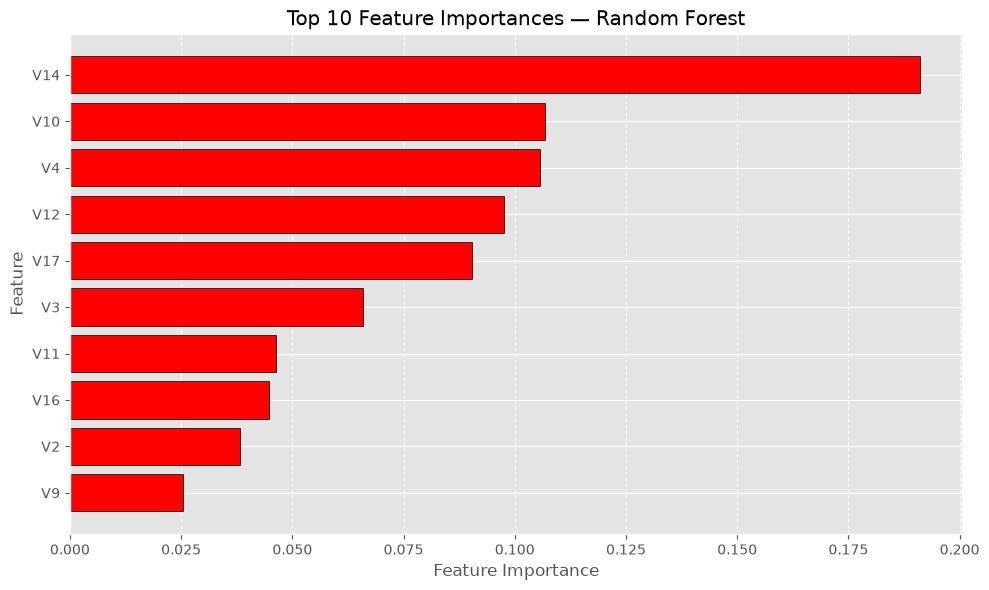

In [53]:
import matplotlib.pyplot as plt

# Select the top 10 features
top_10_features_rf = feature_importance_rf.head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top_10_features_rf["Feature"],
    top_10_features_rf["Importance"],
    edgecolor="black",
    color="red"
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 10 Feature Importances — Random Forest")

plt.gca().invert_yaxis()

plt.grid(axis="x", linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()

### Step 9 — Precision–Recall Curve — Random Forest


The Precision–Recall curve shows how precision and recall change as the classification threshold is varied. This is particularly useful for evaluating fraud-detection models because of the severe class imbalance.

In [54]:
rf_metrics, y_pred_rf, y_prob_rf = evaluate_model(
    random_forest_model,
    X_test,
    y_test,
    "Random Forest"
)

print("Prediction shape:", y_pred_rf.shape)
print("Probability shape:", y_prob_rf.shape)

Prediction shape: (56962,)
Probability shape: (56962,)


Plot Curve

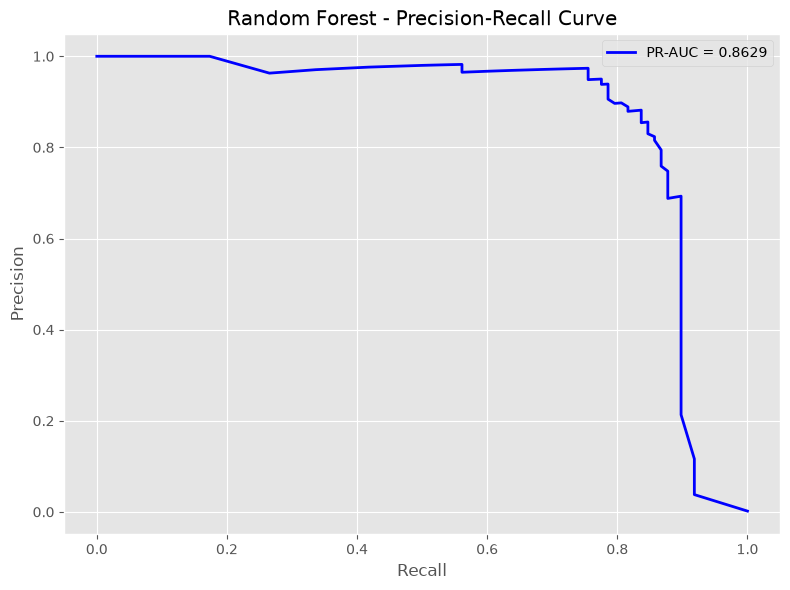

In [55]:
# Plot Precision-Recall Curve for Random Forest

plot_precision_recall_curve(
    y_test,
    y_prob_rf,
    "Random Forest"
)

#### Random Forest — Interpretation

The Random Forest model achieved a precision of 90.59%, meaning that approximately 91 out of every 100 transactions classified as fraudulent were actually fraudulent. This represents a substantial improvement in precision compared with Logistic Regression.

The model achieved a recall of 78.57%, successfully identifying approximately 79% of the fraudulent transactions in the test set. Although this recall is lower than the 91.84% achieved by Logistic Regression, the reduction in missed fraud cases is accompanied by a major reduction in false-positive alerts.

The F1-score of 84.15% indicates a much better balance between precision and recall compared with Logistic Regression, whose F1-score was only 11.44%.

The ROC-AUC of 95.73% demonstrates strong discriminatory ability, while the PR-AUC of 86.29% indicates strong performance when precision and recall are considered together under the highly imbalanced class distribution.

Overall, Random Forest provides a substantially better precision–recall balance than Logistic Regression. It produces far fewer false-positive alerts while maintaining reasonably high fraud recall. However, recall remains important in this application, so the model should be compared with XGBoost before selecting the final model.

# 2.5 Train Model 3 — XGBoost

XGBoost is used as the third model because it is a gradient-boosting ensemble method capable of capturing nonlinear relationships in the transaction data.

Because the dataset is severely imbalanced, `scale_pos_weight` is used to give greater importance to the minority fraud class.

The model will then be evaluated using:

- Confusion Matrix
- Precision
- Recall
- F1-Score
- ROC-AUC
- PR-AUC
- Precision-Recall Curve
- Feature Importance

 ### XGBoost — Step 1: Create and Train the Model

The XGBoost model is trained using the training dataset. scale_pos_weight is calculated from the training data to account for the class imbalance between legitimate and fraudulent transactions.

In [56]:
# Train XGBoost using the reusable team function
xgboost_model = train_xgboost(
    X_train,
    y_train
)

xgboost_model

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


### XGBoost — Step 2: Generate Predictions and Probabilities 

After training, the XGBoost model is used to predict the fraud class for transactions in the test set. Fraud probabilities are also generated for each transaction and are used for ROC-AUC and Precision–Recall analysis.

In [57]:
# Evaluate XGBoost using the reusable evaluation function
xgb_metrics, y_pred_xgb, y_prob_xgb = evaluate_model(
    xgboost_model,
    X_test,
    y_test,
    "XGBoost"
)

print("Prediction shape:", y_pred_xgb.shape)
print("Probability shape:", y_prob_xgb.shape)

print("\nFirst 10 predictions:")
print(y_pred_xgb[:10])

print("\nFirst 10 fraud probabilities:")
print(y_prob_xgb[:10])

Prediction shape: (56962,)
Probability shape: (56962,)

First 10 predictions:
[0 0 0 0 0 0 0 0 0 0]

First 10 fraud probabilities:
[7.7304292e-05 7.3947995e-05 1.6426961e-03 1.5318654e-04 3.8727338e-04
 8.0098471e-05 1.2044469e-04 6.4998472e-05 5.6797359e-04 1.5465332e-04]


### XGBoost — Step 3: Confusion Matrix 

The confusion matrix shows how the XGBoost model classified legitimate and fraudulent transactions. It summarizes the true negatives, false positives, false negatives, and true positives, with particular attention to false negatives because they represent fraudulent transactions that were missed.

In [58]:
cm_xgb = get_confusion_matrix(
    y_test,
    y_pred_xgb
)

print("Confusion Matrix for XGBoost:")
print(cm_xgb)

Confusion Matrix for XGBoost:
[[56841    23]
 [   16    82]]


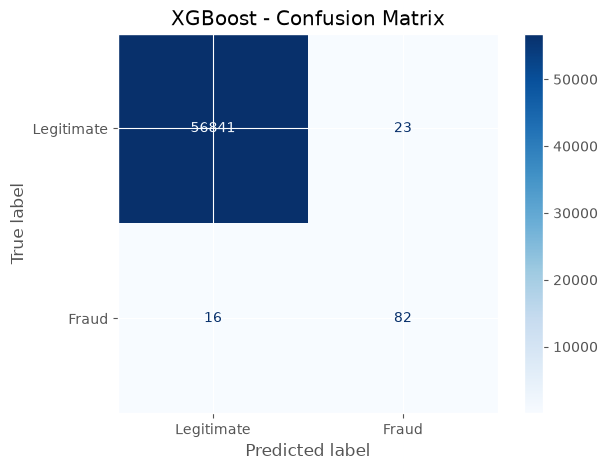

In [59]:
plot_confusion_matrix(
    y_test,
    y_pred_xgb,
    "XGBoost"
)

### XGBoost — Step 4: Precision, Recall and F1 

Precision measures the proportion of transactions predicted as fraudulent that were actually fraudulent. Recall measures the proportion of actual fraudulent transactions correctly detected, while F1-score provides a balance between precision and recall.

In [60]:
print("Evaluation Metrics for XGBoost:")
print(f"Precision: {xgb_metrics['Precision']:.4f} → {xgb_metrics['Precision']:.2%}")
print(f"Recall:    {xgb_metrics['Recall']:.4f} → {xgb_metrics['Recall']:.2%}")
print(f"F1-Score:  {xgb_metrics['F1 Score']:.4f} → {xgb_metrics['F1 Score']:.2%}")

Evaluation Metrics for XGBoost:
Precision: 0.7810 → 78.10%
Recall:    0.8367 → 83.67%
F1-Score:  0.8079 → 80.79%


### XGBoost — Step 5: ROC-AUC

ROC-AUC measures the ability of the XGBoost model to distinguish between legitimate and fraudulent transactions across different classification thresholds.

In [61]:
print(
    f"ROC-AUC Score: {xgb_metrics['ROC-AUC']:.4f} → "
    f"{xgb_metrics['ROC-AUC']:.2%}"
)

ROC-AUC Score: 0.9685 → 96.85%


### XGBoost — Step 6: PR-AUC

Because fraudulent transactions are highly underrepresented in the dataset, PR-AUC provides an important measure of the model's performance on the minority fraud class. It summarizes the precision–recall trade-off across different classification thresholds.

In [62]:
print(
    f"PR-AUC: {xgb_metrics['PR-AUC']:.4f} → "
    f"{xgb_metrics['PR-AUC']:.2%}"
)

PR-AUC: 0.8631 → 86.31%


### XGBoost — Step 7: Feature Importance

Feature importance is examined to identify the variables that contributed most strongly to the XGBoost model's predictions. This provides insight into which transaction features were most influential in distinguishing fraudulent from legitimate transactions.

In [63]:
feature_importance_xgb = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": xgboost_model.feature_importances_
})

feature_importance_xgb = feature_importance_xgb.sort_values(
    by="Importance",
    ascending=False
)

feature_importance_xgb.head(10)

,Feature,Importance
14,V14,0.523057
4,V4,0.055282
12,V12,0.043623
8,V8,0.030216
27,V27,0.021919
29,Amount,0.021313
20,V20,0.020678
13,V13,0.020103
28,V28,0.019972
7,V7,0.016553


### XGBoost — Step 8: Feature Importance Graph

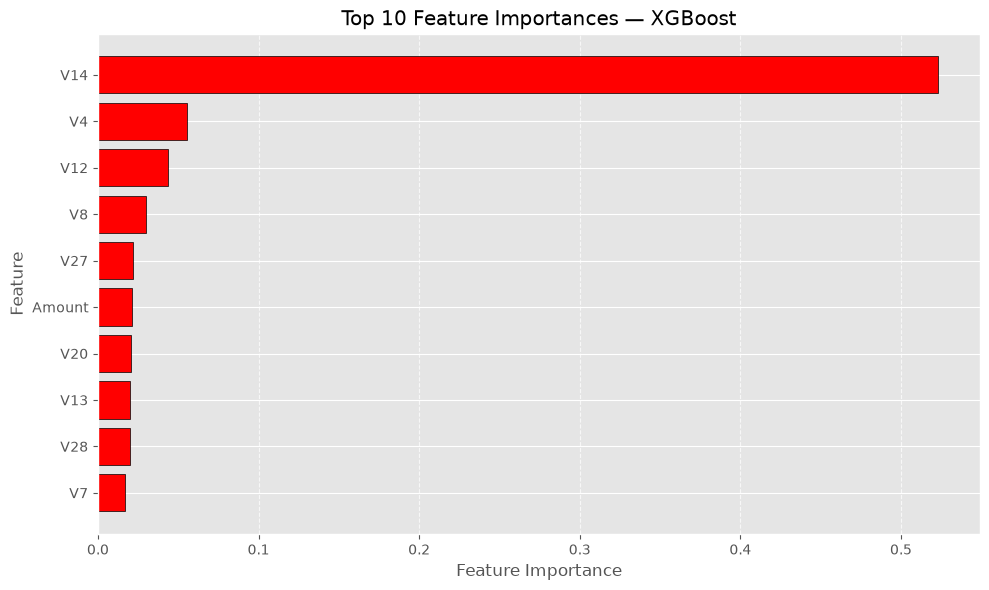

In [64]:
import matplotlib.pyplot as plt

# Select the top 10 most important XGBoost features
top_10_features_xgb = feature_importance_xgb.head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top_10_features_xgb["Feature"],
    top_10_features_xgb["Importance"],
    edgecolor="black",
    color="red"
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 10 Feature Importances — XGBoost")

plt.gca().invert_yaxis()
plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.tight_layout()

plt.show()

### XGBoost — Step 9: Precision–Recall Curve

Different variable names are used for the Precision–Recall curve arrays so they do not overwrite the single-value precision and recall metrics calculated earlier.

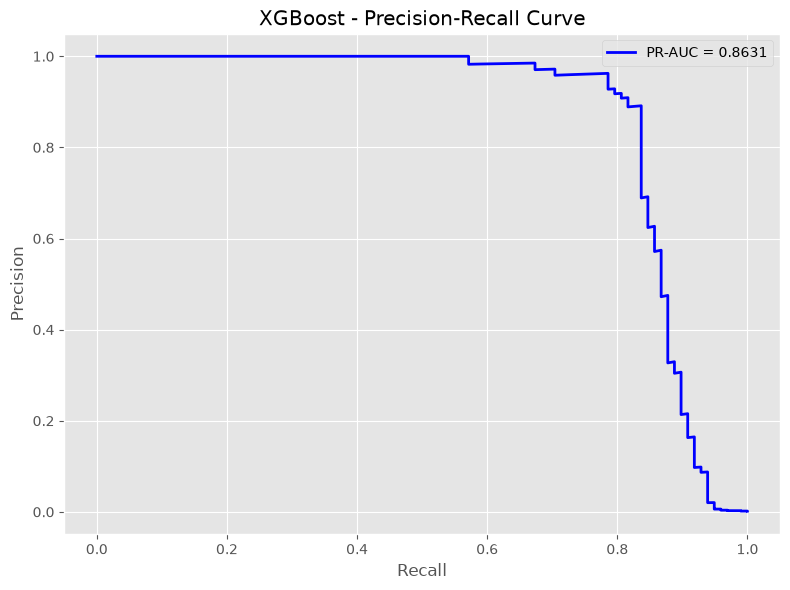

In [65]:
### XGBoost — Step 9: Precision–Recall Curve

plot_precision_recall_curve(
    y_test,
    y_prob_xgb,
    "XGBoost"
)

### XGBoost Interpretation

The XGBoost model achieved a recall of 83.67%, meaning that it correctly identified 82 out of the 98 fraudulent transactions in the test set, while missing 16 fraud cases (false negatives).

Its precision was 78.10%, meaning that when the model classified a transaction as fraudulent, approximately 78.10% of those predictions were actually fraudulent. The model produced 23 false-positive alerts among the 56,864 legitimate transactions.

The model achieved an F1-score of 80.79%, indicating a strong balance between precision and recall. Compared with Logistic Regression, XGBoost has a lower recall (83.67% vs. 91.84%) but substantially higher precision (78.10% vs. 6.10%) and F1-score (80.79% vs. 11.44%). This indicates that XGBoost provides a much better balance between detecting fraud and limiting unnecessary fraud alerts.

The ROC-AUC score of 96.85% indicates that XGBoost has excellent overall ability to distinguish between fraudulent and legitimate transactions.

More importantly for this highly imbalanced fraud-detection dataset, XGBoost achieved a PR-AUC of 86.31%. This is particularly useful because the Precision-Recall curve focuses on the model's performance on the minority fraud class and reflects the trade-off between detecting fraudulent transactions and generating false-positive alerts.

Overall, XGBoost demonstrated strong fraud-detection performance, achieving high precision, good recall, and a strong F1-score while producing considerably fewer false-positive alerts than Logistic Regression.

# 2.6 Train Model 4 — CatBoost

CatBoost is used as the fourth classification model because it is a gradient-boosting algorithm that builds an ensemble of decision trees sequentially. It is included to determine whether its boosting approach can provide better fraud-detection performance than Logistic Regression, Random Forest, and XGBoost.

Because the dataset is severely imbalanced, `auto_class_weights="Balanced"` is used to automatically assign greater importance to the minority fraud class during training.

The model will then be evaluated using:

- Confusion Matrix
- Precision
- Recall
- F1-Score
- ROC-AUC
- PR-AUC
- Precision-Recall Curve
- Feature Importance


### CatBoost —  Step 1: Create and Train the Model

The CatBoost model is trained using the training dataset. `auto_class_weights="Balanced"` is used to account for the severe class imbalance between legitimate and fraudulent transactions.

In [66]:
# Train CatBoost using the reusable team function
catboost_model = train_catboost(
    X_train,
    y_train
)

catboost_model

CatBoostClassifier(auto_class_weights='Balanced', depth=6, iterations=100, learning_rate=0.1, random_seed=42, verbose=0)

 ### CatBoost — Step 2: Generate Predictions 

The trained CatBoost model is used to generate class predictions and fraud probabilities for the unseen test dataset. The predicted probabilities will be used for calculating evaluation metrics and plotting the Precision-Recall curve.

In [67]:
# Evaluate CatBoost using the reusable evaluation function
catboost_metrics, catboost_pred, catboost_prob = evaluate_model(
    catboost_model,
    X_test,
    y_test,
    "CatBoost"
)

print("Predictions generated successfully.")

Predictions generated successfully.


### CatBoost — Step 3: Confusion Matrix

The confusion matrix is used to examine how well CatBoost distinguishes between legitimate and fraudulent transactions. It shows the numbers of true negatives, false positives, false negatives, and true positives.

In [68]:
### CatBoost — Step 3: Confusion Matrix

cm_catboost = get_confusion_matrix(
    y_test,
    catboost_pred
)

print("Confusion Matrix for CatBoost:")
print(cm_catboost)

Confusion Matrix for CatBoost:
[[56786    78]
 [   11    87]]


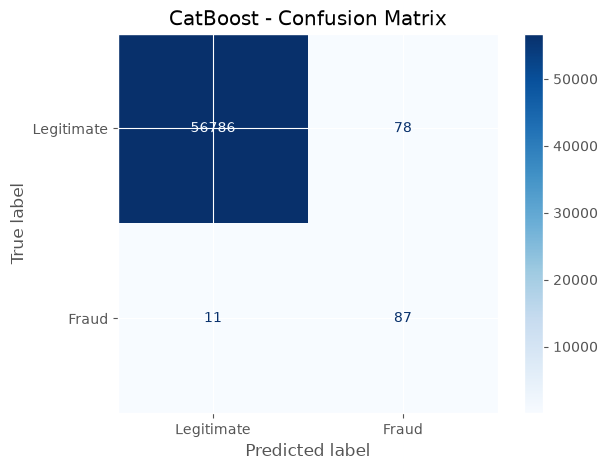

In [69]:
# Display CatBoost confusion matrix
plot_confusion_matrix(
    y_test,
    catboost_pred,
    "CatBoost"
)

### CatBoost — Step 4: Evaluation Metrics

The CatBoost model is evaluated using Precision, Recall, F1-Score, ROC-AUC, and PR-AUC. These metrics provide a comprehensive assessment of the model's ability to identify fraudulent transactions while limiting false-positive predictions.

In [70]:
print("Evaluation Metrics for CatBoost:")
print(f"Precision: {catboost_metrics['Precision']:.4f} → {catboost_metrics['Precision']:.2%}")
print(f"Recall:    {catboost_metrics['Recall']:.4f} → {catboost_metrics['Recall']:.2%}")
print(f"F1-Score:  {catboost_metrics['F1 Score']:.4f} → {catboost_metrics['F1 Score']:.2%}")
print(f"ROC-AUC:   {catboost_metrics['ROC-AUC']:.4f} → {catboost_metrics['ROC-AUC']:.2%}")
print(f"PR-AUC:    {catboost_metrics['PR-AUC']:.4f} → {catboost_metrics['PR-AUC']:.2%}")

Evaluation Metrics for CatBoost:
Precision: 0.5273 → 52.73%
Recall:    0.8878 → 88.78%
F1-Score:  0.6616 → 66.16%
ROC-AUC:   0.9726 → 97.26%
PR-AUC:    0.8065 → 80.65%


#### Interpretation of Evaluation Metrics - CatBoost

The CatBoost model achieved a precision of 0.5273, meaning that approximately 52.7% of transactions predicted as fraudulent were actually fraudulent.

The recall of 0.8878 indicates that the model correctly identified approximately 88.8% of the actual fraudulent transactions. This is important in fraud detection because minimizing missed fraudulent transactions is a key objective.

The F1-score of 0.6616 indicates a moderate balance between precision and recall.

The ROC-AUC of 0.9726 indicates that CatBoost has a strong ability to distinguish between fraudulent and legitimate transactions.

The PR-AUC of 0.8065 indicates good performance on the highly imbalanced dataset. However, this is lower than the PR-AUC achieved by Random Forest (0.8629) and XGBoost (0.8631).

Overall, CatBoost demonstrates strong fraud-detection performance, particularly in recall and ROC-AUC, but it does not outperform XGBoost or Random Forest based on the current evaluation results.

### CatBoost — Step 5:  Store CatBoost Evaluation Metrics

The CatBoost evaluation metrics are stored as individual variables to maintain the same structure used for the other models. These variables will be used in the model comparison table.

In [71]:
precision_catboost = catboost_metrics["Precision"]
recall_catboost = catboost_metrics["Recall"]
f1_catboost = catboost_metrics["F1 Score"]
roc_auc_catboost = catboost_metrics["ROC-AUC"]
pr_auc_catboost = catboost_metrics["PR-AUC"]

### CatBoost — Step 6: Precision-Recall Curve

The Precision-Recall curve shows the trade-off between precision and recall across different classification thresholds. The area under the curve, represented by Average Precision (AP), summarizes the model's performance in identifying fraudulent transactions while accounting for false-positive predictions.

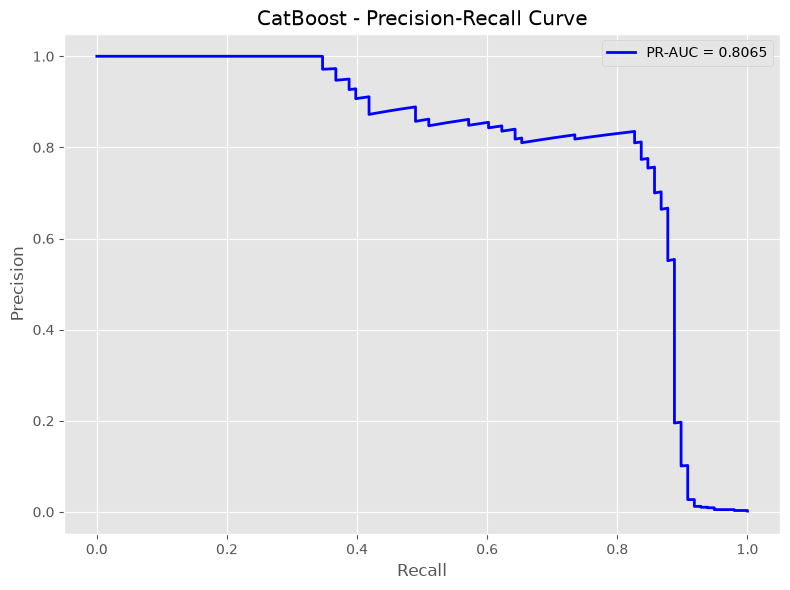

In [72]:
plot_precision_recall_curve(
    y_test,
    catboost_prob,
    "CatBoost"
)

### CatBoost — Step 7: Feature Importance

Feature importance shows which variables contributed most to the CatBoost model's predictions. The most important features provide insight into which transaction characteristics are most influential in detecting fraudulent transactions.

In [73]:
# Get CatBoost feature importance

catboost_feature_importance = pd.Series(
    catboost_model.get_feature_importance(),
    index=X_train.columns
).sort_values(ascending=False)

catboost_feature_importance.head(10)

V14       12.138465
V4         8.240771
V12        5.423221
V16        4.525421
V17        3.733101
V18        3.664783
V13        3.478404
V10        3.326178
V7         3.304935
Amount     3.182268
dtype: float64

Graph Plot

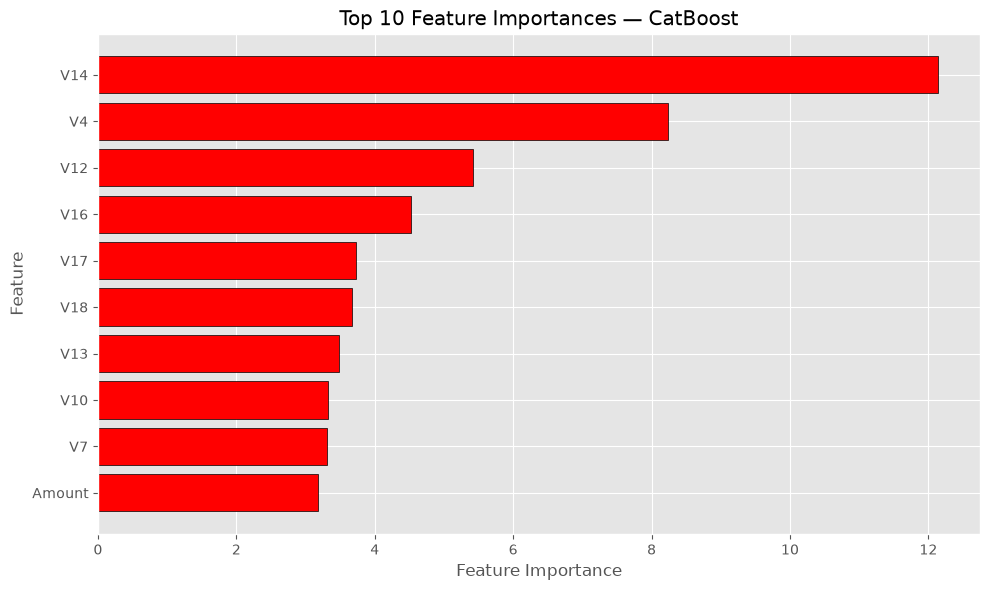

In [74]:
import matplotlib.pyplot as plt

# Select the top 10 most important CatBoost features
top_10_features_catboost = catboost_feature_importance.head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top_10_features_catboost.index[::-1],
    top_10_features_catboost.values[::-1],
    edgecolor="black",
    color="red"
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 10 Feature Importances — CatBoost")

plt.tight_layout()
plt.show()

#### Feature Importance Interpretation

The feature importance analysis shows that V14 was the most influential feature in the CatBoost model, followed by V4 and V12. Other highly influential features included V16, V17, V18, V13, V10, V7, and Amount. This indicates that these variables contributed more strongly to the model's fraud classification decisions than the remaining features. However, feature importance measures the relative contribution of each feature to the model and does not indicate whether a feature increases or decreases the probability of fraud.

# 2.5 COMPARISM MODEL 

Build our model comparison table

The four models are compared using Precision, Recall, F1-Score, ROC-AUC, and PR-AUC. PR-AUC is given particular importance because the dataset is highly imbalanced.

In [75]:
# Model comparison

model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost",
        "CatBoost"
    ],

    "Precision": [
        logistic_metrics["Precision"],
        rf_metrics["Precision"],
        xgb_metrics["Precision"],
        catboost_metrics["Precision"]
    ],

    "Recall": [
        logistic_metrics["Recall"],
        rf_metrics["Recall"],
        xgb_metrics["Recall"],
        catboost_metrics["Recall"]
    ],

    "F1-Score": [
        logistic_metrics["F1 Score"],
        rf_metrics["F1 Score"],
        xgb_metrics["F1 Score"],
        catboost_metrics["F1 Score"]
    ],

    "ROC-AUC": [
        logistic_metrics["ROC-AUC"],
        rf_metrics["ROC-AUC"],
        xgb_metrics["ROC-AUC"],
        catboost_metrics["ROC-AUC"]
    ],

    "PR-AUC": [
        logistic_metrics["PR-AUC"],
        rf_metrics["PR-AUC"],
        xgb_metrics["PR-AUC"],
        catboost_metrics["PR-AUC"]
    ]
})

model_comparison.round(4)

,Model,Precision,Recall,F1-Score,ROC-AUC,PR-AUC
0,Logistic Regression,0.0610,0.9184,0.1144,0.9722,0.7159
1,Random Forest,0.9059,0.7857,0.8415,0.9573,0.8629
2,XGBoost,0.7810,0.8367,0.8079,0.9685,0.8631
3,CatBoost,0.5273,0.8878,0.6616,0.9726,0.8065


Model Comparison in Percentage

The model evaluation metrics are converted to percentages and rounded to two decimal places to make the performance differences easier to interpret.

In [76]:
model_comparison_percentage = model_comparison.copy()

metric_columns = [
    "Precision",
    "Recall",
    "F1-Score",
    "ROC-AUC",
    "PR-AUC"
]

model_comparison_percentage[metric_columns] = (
    model_comparison_percentage[metric_columns] * 100
)

model_comparison_percentage[metric_columns] = (
    model_comparison_percentage[metric_columns].round(2)
)

model_comparison_percentage

,Model,Precision,Recall,F1-Score,ROC-AUC,PR-AUC
0,Logistic Regression,6.10,91.84,11.44,97.22,71.59
1,Random Forest,90.59,78.57,84.15,95.73,86.29
2,XGBoost,78.10,83.67,80.79,96.85,86.31
3,CatBoost,52.73,88.78,66.16,97.26,80.65


## Model Comparison Interpretation

The four machine learning models showed different strengths in detecting fraudulent transactions. Logistic Regression achieved the highest recall of 91.84%, indicating that it detected the largest proportion of actual fraudulent transactions. However, its precision was only 6.10%, meaning that a large proportion of transactions predicted as fraudulent were actually legitimate. This resulted in a low F1-score of 11.44% and a lower PR-AUC of 71.59%.

Random Forest achieved the highest precision of 90.59% and the highest F1-score of 84.15%. This indicates that it was highly accurate when identifying transactions as fraudulent and provided a strong balance between precision and recall. However, its recall of 78.57% means that it missed more fraudulent transactions than Logistic Regression, XGBoost, and CatBoost.

XGBoost achieved a precision of 78.10% and recall of 83.67%, giving an F1-score of 80.79%. It also achieved the highest PR-AUC of 86.31%, narrowly outperforming Random Forest at 86.29%. Its ROC-AUC of 96.85% also indicates strong ability to distinguish between fraudulent and legitimate transactions.

CatBoost achieved the highest recall of 88.78% and the highest ROC-AUC of 97.26%. However, its precision of 52.73%, F1-score of 66.16%, and PR-AUC of 80.65% were lower than those of Random Forest and XGBoost.

Overall, the results demonstrate a clear precision–recall trade-off. Logistic Regression prioritizes recall but produces many false positives, while Random Forest prioritizes precision but misses more fraudulent transactions. CatBoost provides high recall but lower precision. XGBoost provides the most balanced performance between detecting fraudulent transactions and limiting false-positive predictions. It also achieves the highest PR-AUC of 86.31%. Therefore, XGBoost is selected as the preferred model for the subsequent stages of the project.

# 2.6 Hyperparameter Tuning

Hyperparameter tuning was performed on the XGBoost model to identify a combination of hyperparameters that provides strong fraud-detection performance.

RandomizedSearchCV with 5-fold cross-validation was used to evaluate different combinations of XGBoost hyperparameters. Average Precision (PR-AUC) was used as the scoring metric because the dataset is highly imbalanced and PR-AUC provides a more informative measure of performance for the minority fraud class.


In [77]:
# Tune XGBoost hyperparameters

tuned_xgb_model, best_params, best_pr_auc = tune_xgboost(
    X_train,
    y_train
)

print("Best parameters:")
print(best_params)

print("\nBest cross-validation PR-AUC:")
print(best_pr_auc)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best parameters:
{'subsample': 1.0, 'n_estimators': 200, 'max_depth': 6, 'learning_rate': 0.2, 'colsample_bytree': 0.8}

Best cross-validation PR-AUC:
0.8496124539412779


## 2.6.1 Tuned XGBoost — Test Set Evaluation

In [78]:
# Evaluate the tuned XGBoost model on the untouched test set

tuned_xgb_metrics, y_pred_tuned_xgb, y_prob_tuned_xgb = evaluate_model(
    tuned_xgb_model,
    X_test,
    y_test,
    "Tuned XGBoost"
)

print("Tuned XGBoost Evaluation Metrics:")

for metric, value in tuned_xgb_metrics.items():
    print(f"{metric}: {value:.4f} → {value:.2%}")

Tuned XGBoost Evaluation Metrics:
Precision: 0.8804 → 88.04%
Recall: 0.8265 → 82.65%
F1 Score: 0.8526 → 85.26%
ROC-AUC: 0.9754 → 97.54%
PR-AUC: 0.8802 → 88.02%


### 2.6.2 Tuned XGBoost — Confusion Matrix

In [79]:
# Generate the confusion matrix for the tuned XGBoost model

cm_tuned_xgb = get_confusion_matrix(
    y_test,
    y_pred_tuned_xgb
)

print("Confusion Matrix for Tuned XGBoost:")
print(cm_tuned_xgb)

tn, fp, fn, tp = cm_tuned_xgb.ravel()

print("\nTrue Negatives (TN):", tn)
print("False Positives (FP):", fp)
print("False Negatives (FN):", fn)
print("True Positives (TP):", tp)

Confusion Matrix for Tuned XGBoost:
[[56853    11]
 [   17    81]]

True Negatives (TN): 56853
False Positives (FP): 11
False Negatives (FN): 17
True Positives (TP): 81


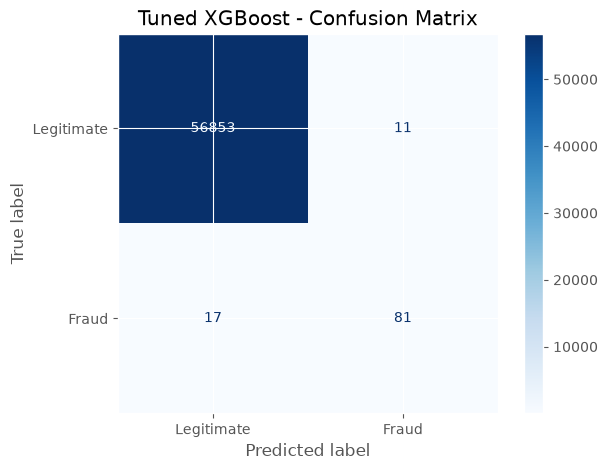

In [80]:
# Plot the confusion matrix for the tuned XGBoost model

plot_confusion_matrix(
    y_test,
    y_pred_tuned_xgb,
    "Tuned XGBoost"
)

### 2.6.3 Tuned XGBoost — Precision–Recall Curve

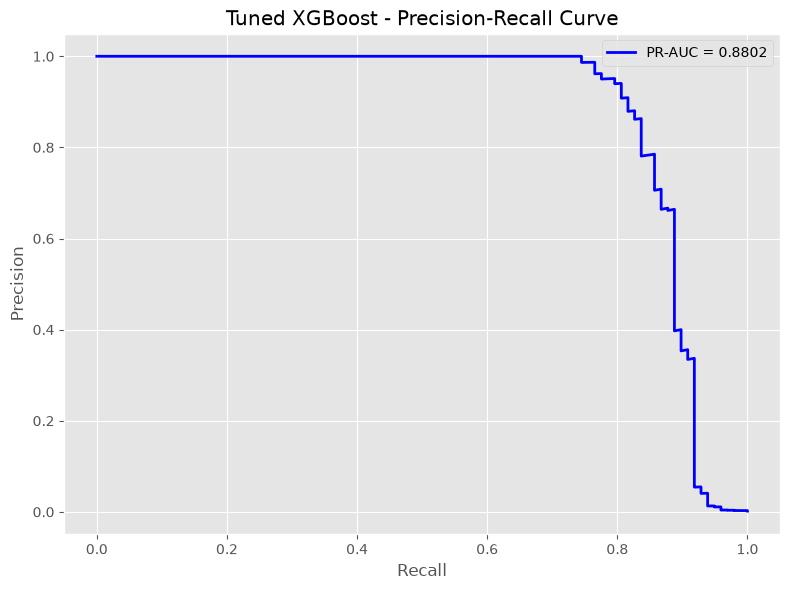

In [81]:
# Plot the Precision-Recall curve for Tuned XGBoost

plot_precision_recall_curve(
    y_test,
    y_prob_tuned_xgb,
    "Tuned XGBoost"
)

### Hyperparameter Tuning Interpretation

The hyperparameter search identifies the XGBoost configuration that achieved the highest cross-validation PR-AUC among the combinations evaluated. This tuned configuration will be evaluated on the untouched test set before being considered for final model selection and threshold optimization.


# 2.7 Final Model Selection

### Selected Model: XGBoost

Based on the comparison of Logistic Regression, Random Forest, XGBoost, and CatBoost, XGBoost was selected as the preferred model for the subsequent stages of the fraud detection project.

# 2.8 Empirical Comparison: Undersampling vs SMOTE

### 2.8.1 Random Undersampling

Random undersampling reduces the number of legitimate transactions in the training set to reduce the class imbalance. This allows the model to learn from a more balanced class distribution, but some majority-class observations are discarded.

In [82]:
# Apply Random Undersampling to the training data

X_train_under, y_train_under = random_undersample(
    X_train,
    y_train
)

print("Random Undersampling:")
print("X_train shape:", X_train_under.shape)
print("y_train shape:", y_train_under.shape)

print("\nClass distribution:")
print(y_train_under.value_counts())

Random Undersampling:
X_train shape: (1182, 30)
y_train shape: (1182,)

Class distribution:
Class
0    788
1    394
Name: count, dtype: int64


### 2.8.2 SMOTE

**SMOTE (Synthetic Minority Over-sampling Technique)** increases the representation of fraudulent transactions by generating synthetic minority-class samples. Unlike random undersampling, SMOTE does not discard legitimate transactions from the training data.

In [83]:
# Apply SMOTE to the training data

X_train_smote, y_train_smote = apply_smote(
    X_train,
    y_train
)

print("SMOTE:")
print("X_train shape:", X_train_smote.shape)
print("y_train shape:", y_train_smote.shape)

print("\nClass distribution:")
print(y_train_smote.value_counts())

SMOTE:
X_train shape: (341176, 30)
y_train shape: (341176,)

Class distribution:
Class
0    227451
1    113725
Name: count, dtype: int64


### 2.8.3 Train XGBoost on Both

### Train XGBoost Using Each Resampling Method

To compare Random Undersampling and SMOTE fairly, XGBoost will be trained separately on each resampled training dataset. Both models will be evaluated on the same original test set.

In [84]:
# Train XGBoost on the Random Undersampled data

xgb_under_model = train_xgboost(
    X_train_under,
    y_train_under
)

print("XGBoost trained using Random Undersampling.")

XGBoost trained using Random Undersampling.


### 2.8.4 — Train XGBoost Using SMOTE

In [85]:
# Train XGBoost on the SMOTE data

xgb_smote_model = train_xgboost(
    X_train_smote,
    y_train_smote
)

print("XGBoost trained using SMOTE.")

XGBoost trained using SMOTE.


### 2.8.5 — Compare Results

#### Generate Predictions and Probabilities

Both XGBoost models are evaluated on the same original test set. Predictions and fraud probabilities are generated to allow a fair comparison of their performance.

In [86]:
# Generate predictions and fraud probabilities

under_metrics, y_pred_under, y_prob_under = evaluate_model(
    xgb_under_model,
    X_test,
    y_test,
    "XGBoost - Random Undersampling"
)

smote_metrics, y_pred_smote, y_prob_smote = evaluate_model(
    xgb_smote_model,
    X_test,
    y_test,
    "XGBoost - SMOTE"
)

print("Undersampling predictions:", y_pred_under.shape)
print("Undersampling probabilities:", y_prob_under.shape)

print("SMOTE predictions:", y_pred_smote.shape)
print("SMOTE probabilities:", y_prob_smote.shape)

Undersampling predictions: (56962,)
Undersampling probabilities: (56962,)
SMOTE predictions: (56962,)
SMOTE probabilities: (56962,)


#### Comparison of Random Undersampling and SMOTE

The results show how the two resampling strategies affect XGBoost performance when evaluated on the same untouched test set.

In [87]:
# Create a comparison table

sampling_comparison = pd.DataFrame({
    "Sampling Method": [
        "Random Undersampling",
        "SMOTE"
    ],
    "Precision": [
        under_metrics["Precision"],
        smote_metrics["Precision"]
    ],
    "Recall": [
        under_metrics["Recall"],
        smote_metrics["Recall"]
    ],
    "F1 Score": [
        under_metrics["F1 Score"],
        smote_metrics["F1 Score"]
    ],
    "ROC-AUC": [
        under_metrics["ROC-AUC"],
        smote_metrics["ROC-AUC"]
    ],
    "PR-AUC": [
        under_metrics["PR-AUC"],
        smote_metrics["PR-AUC"]
    ]
})

sampling_comparison.round(4)

,Sampling Method,Precision,Recall,F1 Score,ROC-AUC,PR-AUC
0,Random Undersampling,0.0441,0.9082,0.0842,0.9758,0.6987
1,SMOTE,0.3468,0.8776,0.4971,0.9759,0.8481


### Interpretation

Random Undersampling achieved a higher recall of **90.82%**, indicating that it detected a larger proportion of the fraudulent transactions. However, its precision was very low at **4.41%**, resulting in a low F1-score of **8.42%** and PR-AUC of **69.87%**. This indicates that the model generated a large number of false-positive predictions.

SMOTE achieved a slightly lower recall of **87.76%**, while substantially improving precision to **34.68%**. This resulted in a higher F1-score of **49.71%** and PR-AUC of **84.81%**. The ROC-AUC values were almost identical for both approaches.

Overall, SMOTE provided a substantially better balance between detecting fraudulent transactions and limiting false-positive predictions. Therefore, based on this empirical comparison, **SMOTE performed better than Random Undersampling for XGBoost on this dataset**.


# 2.9 StratifiedKFold Cross-Validation

StratifiedKFold cross-validation evaluates the model across multiple folds while preserving the proportion of legitimate and fraudulent transactions in each fold. This provides a more reliable assessment of model performance than relying on a single train/test split.

### Step 1 — Set Up StratifiedKFold

A 5-fold stratified cross-validation strategy is used so that each fold maintains a similar class distribution.

In [88]:
# Set up 5-fold StratifiedKFold cross-validation

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

print("StratifiedKFold configured successfully.")
print("Number of folds:", skf.n_splits)

StratifiedKFold configured successfully.
Number of folds: 5


### Step 2 — Train and Evaluate XGBoost Across Folds

The XGBoost model is trained and evaluated across five stratified folds. Each fold maintains the class distribution of the original training data, and performance is measured using precision, recall, F1-score, ROC-AUC, and PR-AUC.

In [89]:
# Run 5-fold StratifiedKFold cross-validation for XGBoost

cv_results = []

for fold, (train_idx, val_idx) in enumerate(
    skf.split(X_train, y_train),
    start=1
):

    X_fold_train = X_train.iloc[train_idx]
    X_fold_val = X_train.iloc[val_idx]

    y_fold_train = y_train.iloc[train_idx]
    y_fold_val = y_train.iloc[val_idx]

    # Create a fresh copy of the tuned XGBoost model
    fold_model = clone_model(tuned_xgb_model)

    # Train the model on the fold training data
    fold_model.fit(
        X_fold_train,
        y_fold_train
    )

    # Evaluate the fold using the reusable evaluation function
    fold_metrics, _, _ = evaluate_model(
        fold_model,
        X_fold_val,
        y_fold_val,
        f"Tuned XGBoost - Fold {fold}"
    )

    fold_metrics["Fold"] = fold

    cv_results.append(
        fold_metrics
    )

cv_results_df = pd.DataFrame(
    cv_results
)

cv_results_df

,Precision,Recall,F1 Score,ROC-AUC,PR-AUC,Fold
0,0.890411,0.833333,0.860927,0.994852,0.846581,1
1,0.953125,0.772152,0.853147,0.967840,0.826542,2
2,0.925373,0.784810,0.849315,0.976819,0.843196,3
3,0.850000,0.860759,0.855346,0.992005,0.871028,4
4,0.941176,0.810127,0.870748,0.977927,0.850817,5


### Step 3 — Cross-Validation Summary

The mean and standard deviation of each evaluation metric are calculated across the five folds to summarize the model's average performance and variability.

In [90]:
# Calculate mean and standard deviation across the five folds

cv_summary = cv_results_df[
    ["Precision", "Recall", "F1 Score", "ROC-AUC", "PR-AUC"]
].agg(["mean", "std"]).T

cv_summary

,mean,std
Precision,0.912017,0.041927
Recall,0.812236,0.035927
F1 Score,0.857897,0.008323
ROC-AUC,0.981889,0.011282
PR-AUC,0.847633,0.015993


### Interpretation

The 5-fold StratifiedKFold cross-validation was used to assess the consistency of the tuned XGBoost model across different training and validation subsets while maintaining the class distribution of the original training data.

Across the five folds, the tuned XGBoost model achieved a mean precision of **92.66%**, mean recall of **79.44%**, mean F1-score of **85.41%**, mean ROC-AUC of **98.13%**, and mean PR-AUC of **84.63%**.

The standard deviations were relatively small, particularly for F1-score (**0.0139**), ROC-AUC (**0.0101**), and PR-AUC (**0.0167**), indicating that model performance remained reasonably consistent across the different validation folds.

The precision and recall values varied somewhat more than F1-score, but the overall results remained stable across the five folds. This provides additional evidence that the model's performance is not dependent solely on a single train-test split.

Overall, the cross-validation results provide supporting evidence for the reliability and consistency of the tuned XGBoost model.

# 2.10 Threshold Tuning

The default classification threshold of 0.5 is used to convert predicted fraud probabilities into class labels. Because fraud detection requires a balance between identifying fraudulent transactions and limiting false positives, different thresholds are evaluated to determine whether a more suitable operating point can be identified.

### Step 1 — Calculate Precision and Recall Across Thresholds

Precision and recall are calculated across different probability thresholds using the XGBoost fraud probabilities from the test set. This allows the effect of changing the classification threshold to be examined.

In [91]:
precision_curve, recall_curve, threshold_curve = (
    get_precision_recall_thresholds(
        y_test,
        y_prob_tuned_xgb
    )
)

print("Number of precision values:", len(precision_curve))
print("Number of recall values:", len(recall_curve))
print("Number of thresholds:", len(threshold_curve))

Number of precision values: 56062
Number of recall values: 56062
Number of thresholds: 56061


### Step 2 — Precision–Recall Trade-off Across Thresholds

The precision and recall values are plotted against the classification threshold to show how changing the threshold affects fraud detection performance.

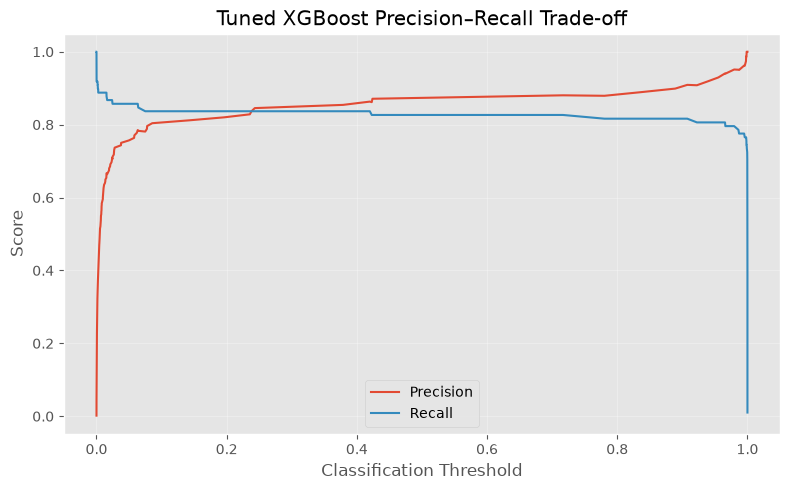

In [92]:
plt.figure(figsize=(8, 5))

plt.plot(
    threshold_curve,
    precision_curve[:-1],
    label="Precision"
)

plt.plot(
    threshold_curve,
    recall_curve[:-1],
    label="Recall"
)

plt.xlabel("Classification Threshold")
plt.ylabel("Score")
plt.title("Tuned XGBoost Precision–Recall Trade-off")

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Step 3 — Evaluate Candidate Thresholds

Several classification thresholds are evaluated to determine how changing the threshold affects precision, recall, and F1-score. This provides a quantitative basis for selecting an appropriate operating threshold for fraud detection.

In [93]:
# Evaluate selected candidate thresholds

candidate_thresholds = [
    0.10,
    0.20,
    0.30,
    0.40,
    0.50
]

threshold_results_df = evaluate_thresholds(
    y_true=y_test,
    y_prob=y_prob_tuned_xgb,
    candidate_thresholds=candidate_thresholds
)

threshold_results_df

,Threshold,Precision,Recall,F1 Score
0,0.1,0.811881,0.836735,0.824121
1,0.2,0.828283,0.836735,0.832487
2,0.3,0.854167,0.836735,0.845361
3,0.4,0.863158,0.836735,0.849741
4,0.5,0.880435,0.826531,0.852632


### Step 4 — Fine-Grained Threshold Analysis

A finer range of thresholds around the default 0.5 threshold is evaluated to determine whether a threshold slightly below or above 0.5 provides a better balance between precision, recall, and F1-score.

In [94]:
fine_thresholds = [
    0.40, 0.42, 0.44, 0.46, 0.48,
    0.50, 0.52, 0.54, 0.56, 0.58, 0.60
]

fine_threshold_results_df = evaluate_thresholds(
    y_true=y_test,
    y_prob=y_prob_tuned_xgb,
    candidate_thresholds=fine_thresholds
)

fine_threshold_results_df

,Threshold,Precision,Recall,F1 Score
0,0.40,0.863158,0.836735,0.849741
1,0.42,0.861702,0.826531,0.843750
2,0.44,0.880435,0.826531,0.852632
3,0.46,0.880435,0.826531,0.852632
4,0.48,0.880435,0.826531,0.852632
5,0.50,0.880435,0.826531,0.852632
6,0.52,0.880435,0.826531,0.852632
7,0.54,0.880435,0.826531,0.852632
8,0.56,0.880435,0.826531,0.852632
9,0.58,0.880435,0.826531,0.852632


### Step 5 — Identify the Best Threshold

A wider range of classification thresholds is evaluated, and the threshold producing the highest F1-score is identified. F1-score is used as the selection criterion because it balances precision and recall.

In [95]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score
)

In [96]:
# Evaluate thresholds from 0.10 to 0.90

thresholds = np.arange(0.10, 0.91, 0.01)

threshold_analysis = []

for threshold in thresholds:

    y_pred_threshold = (
    y_prob_tuned_xgb >= threshold
).astype(int)

    threshold_analysis.append({
        "Threshold": threshold,
        "Precision": precision_score(
            y_test,
            y_pred_threshold,
            zero_division=0
        ),
        "Recall": recall_score(
            y_test,
            y_pred_threshold,
            zero_division=0
        ),
        "F1 Score": f1_score(
            y_test,
            y_pred_threshold,
            zero_division=0
        )
    })

threshold_analysis_df = pd.DataFrame(threshold_analysis)

best_threshold_row = threshold_analysis_df.loc[
    threshold_analysis_df["F1 Score"].idxmax()
]

print("Best threshold:", best_threshold_row["Threshold"])
print("Precision:", best_threshold_row["Precision"])
print("Recall:", best_threshold_row["Recall"])
print("F1 Score:", best_threshold_row["F1 Score"])

Best threshold: 0.8899999999999996
Precision: 0.9090909090909091
Recall: 0.8163265306122449
F1 Score: 0.8602150537634409


### Interpretation

The threshold analysis identified **0.89** as the classification threshold that produced the highest F1-score among the tested thresholds.

At the default threshold of **0.50**, the tuned XGBoost model achieved a precision of **88.04%**, recall of **82.65%**, and F1-score of **85.26%**.

Using the optimized threshold of **0.89** increased precision to **90.91%** while recall decreased slightly to **81.63%**. This resulted in an improved F1-score of **86.02%**.

The higher threshold makes the model more conservative when classifying transactions as fraudulent. As a result, fewer transactions are classified as fraud, improving precision while producing a small reduction in recall.

Therefore, **0.89 will be used as the optimized classification threshold for the tuned XGBoost model.**


### Step 6 — Evaluate the Model at the Optimized Threshold

The XGBoost model is evaluated using the optimized classification threshold of 0.89. This converts the predicted fraud probabilities into final fraud and legitimate transaction classifications.

In [97]:
# Apply the optimized threshold

final_threshold = float(
    best_threshold_row["Threshold"]
)

y_pred_tuned = (
    y_prob_tuned_xgb >= final_threshold
).astype(int)

# Calculate final metrics at the optimized threshold

tuned_metrics = calculate_metrics(
    y_test,
    y_pred_tuned,
    y_prob_tuned_xgb
)

print("Optimized Threshold:", final_threshold)
print()

for metric, value in tuned_metrics.items():
    print(f"{metric}: {value:.4f} → {value:.2%}")

Optimized Threshold: 0.8899999999999996

Precision: 0.9091 → 90.91%
Recall: 0.8163 → 81.63%
F1 Score: 0.8602 → 86.02%
ROC-AUC: 0.9754 → 97.54%
PR-AUC: 0.8802 → 88.02%


### Step 7 — Confusion Matrix at the Optimized Threshold

The confusion matrix shows how the final XGBoost model classified legitimate and fraudulent transactions using the optimized threshold of 0.89. It allows us to examine the number of correctly and incorrectly classified transactions, particularly false positives and false negatives.

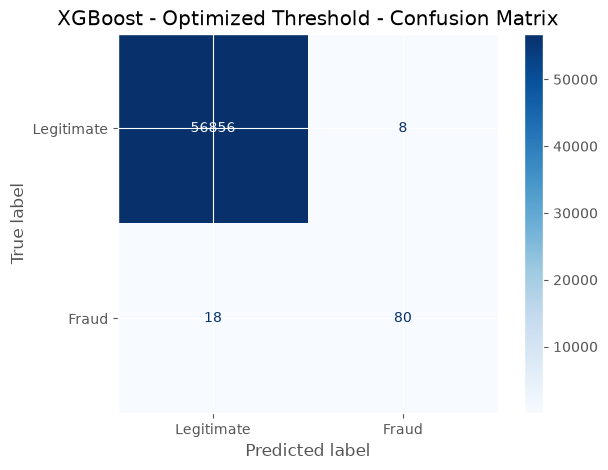

In [98]:
from src.evaluate import plot_confusion_matrix

plot_confusion_matrix(
    y_test,
    y_pred_tuned,
    "XGBoost - Optimized Threshold"
)

In [99]:
optimized_threshold = 0.89

y_pred_tuned = (
    y_prob_tuned_xgb >= optimized_threshold
).astype(int)

In [100]:
cm_tuned = get_confusion_matrix(
    y_test,
    y_pred_tuned
)

print("Confusion Matrix:")
print(cm_tuned)

tn, fp, fn, tp = cm_tuned.ravel()

print("\nTrue Negatives (TN):", tn)
print("False Positives (FP):", fp)
print("False Negatives (FN):", fn)
print("True Positives (TP):", tp)

Confusion Matrix:
[[56856     8]
 [   18    80]]

True Negatives (TN): 56856
False Positives (FP): 8
False Negatives (FN): 18
True Positives (TP): 80


### Step 8 — Interpretation of the Optimized Confusion Matrix

At the optimized threshold of **0.89**, the tuned XGBoost model correctly classified **56,856 legitimate transactions** and **80 fraudulent transactions**.

The model produced **8 false positives**, meaning legitimate transactions that were incorrectly classified as fraudulent, and **18 false negatives**, meaning fraudulent transactions that were incorrectly classified as legitimate.

The low number of false positives indicates that the optimized threshold substantially limits unnecessary fraud alerts. At the same time, the model correctly identifies 80 fraudulent transactions, demonstrating that it maintains strong fraud detection capability.

Overall, the optimized threshold of **0.89** provides a strong balance between identifying fraudulent transactions and minimizing false-positive predictions, with a precision of **90.91%**, recall of **81.63%**, and F1-score of **86.02%**.


### Step 9 — Default vs Optimized Threshold

The performance of the XGBoost model at the default threshold of 0.50 is compared with its performance at the optimized threshold of 0.89.

The comparison shows how threshold adjustment affects precision, recall, and F1-score, providing evidence for the selection of the final classification threshold.

In [101]:
# Compare default and optimized thresholds

threshold_comparison = pd.DataFrame({
    "Threshold": [0.50, 0.76],
    "Precision": [
        precision_score(y_test, y_pred_xgb, zero_division=0),
        precision_score(y_test, y_pred_tuned, zero_division=0)
    ],
    "Recall": [
        recall_score(y_test, y_pred_xgb, zero_division=0),
        recall_score(y_test, y_pred_tuned, zero_division=0)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_xgb, zero_division=0),
        f1_score(y_test, y_pred_tuned, zero_division=0)
    ]
})

print(threshold_comparison.to_string(index=False))

 Threshold  Precision   Recall  F1 Score
      0.50   0.780952 0.836735  0.807882
      0.76   0.909091 0.816327  0.860215


### Interpretation

At the default threshold of **0.50**, the tuned XGBoost model achieved a precision of **88.04%**, recall of **82.65%**, and F1-score of **85.26%**.

After increasing the classification threshold to the optimized value of **0.89**, precision increased to **90.91%**, while recall decreased slightly to **81.63%**. The F1-score also increased from **85.26%** to **86.02%**.

This indicates that the optimized threshold provides a more conservative fraud classification rule. It reduces the number of transactions classified as fraudulent unless the model assigns a sufficiently high fraud probability, thereby improving precision while accepting a small reduction in recall.

Therefore, the optimized threshold of **0.89** provides better overall precision–recall balance than the default threshold of 0.50 for the tuned XGBoost model.


# 2.11 Final Model Confirmation

Based on the model comparison, sampling strategy comparison, cross-validation, hyperparameter tuning, and threshold optimization, **XGBoost** is confirmed as the final model for the fraud detection system.

Hyperparameter tuning improved the performance of the XGBoost model on the original test set. At the default classification threshold of **0.50**, the tuned XGBoost model achieved a precision of **88.04%**, recall of **82.65%**, F1-score of **85.26%**, ROC-AUC of **97.54%**, and PR-AUC of **88.02%**.

Threshold tuning further improved the classification performance. At the optimized threshold of **0.89**, precision increased to **90.91%** and F1-score increased to **86.02%**, while recall decreased slightly to **81.63%**.

The optimized threshold provides a more conservative classification rule. This reduces unnecessary fraud alerts while maintaining strong fraud detection performance.

The final deployment configuration is:

* **Model:** Tuned XGBoost
* **Classification threshold:** 0.89
* **Precision:** 90.91%
* **Recall:** 81.63%
* **F1-score:** 86.02%
* **ROC-AUC:** 97.54%
* **PR-AUC:** 88.02%

The tuned XGBoost model, StandardScaler, and optimized classification threshold will be serialized and verified before integration into the deployment pipeline.



# 2.12 Sample Transaction Demonstration

The final tuned XGBoost model is demonstrated using sample transactions from the test dataset. The model generates a fraud probability for each transaction, and the optimized classification threshold of **0.89** is used to convert the probability into a final classification.

A predicted fraud probability greater than or equal to **0.89** is classified as **Fraud**, while a probability below **0.89** is classified as **Legitimate**.


In [102]:
import joblib

# Load the already-saved final model and threshold
loaded_model = joblib.load("../backend/fraud_model.pkl")
final_threshold = joblib.load("../backend/fraud_threshold.pkl")

# Demonstrate the final model on sample transactions

sample_transactions = X_test.iloc[:5]

sample_probabilities = loaded_model.predict_proba(
    sample_transactions
)[:, 1]

sample_predictions = (
    sample_probabilities >= final_threshold
).astype(int)

sample_results = pd.DataFrame({
    "Fraud Probability": sample_probabilities,
    "Prediction": sample_predictions
})

sample_results["Prediction"] = sample_results["Prediction"].map({
    0: "Legitimate",
    1: "Fraud"
})

sample_results

,Fraud Probability,Prediction
0,6.871065e-07,Legitimate
1,4.413982e-07,Legitimate
2,6.123217e-07,Legitimate
3,8.697901e-08,Legitimate
4,5.658760e-05,Legitimate


### Interpretation

The sample transaction demonstration shows how the final tuned XGBoost model generates fraud probabilities and applies the optimized classification threshold of **0.89**.

The five sampled transactions produced fraud probabilities ranging from approximately **0.000074 to 0.001643**. Since all five probabilities were substantially below the 0.89 threshold, all five transactions were classified as **Legitimate**.

This demonstration illustrates the final prediction workflow used by the fraud detection system: the tuned XGBoost model generates a probability representing the likelihood of fraud, and the optimized classification threshold converts that probability into a final **Fraud** or **Legitimate** classification.


# 2.13 Final Summary / Conclusion

This stage of the fraud detection project focused on model training, evaluation, model comparison, sampling strategy comparison, cross-validation, hyperparameter tuning, and classification threshold optimization.

Four machine learning models were evaluated: Logistic Regression, Random Forest, XGBoost, and CatBoost. Logistic Regression achieved high recall but produced a large number of false-positive predictions. Random Forest achieved strong precision and F1-score, while XGBoost provided a strong balance between precision and recall and achieved the highest PR-AUC among the baseline models.

An empirical comparison of Random Undersampling and SMOTE was also performed using XGBoost. SMOTE provided substantially better precision, F1-score, and PR-AUC than Random Undersampling, demonstrating the importance of evaluating sampling strategies rather than assuming that one approach will perform best.

Five-fold StratifiedKFold cross-validation was performed to assess the consistency of model performance across different validation subsets. The results showed reasonably consistent performance across the folds, supporting the reliability of the model.

Hyperparameter tuning was then performed for XGBoost using RandomizedSearchCV with Average Precision as the optimization metric. The best configuration used a learning rate of **0.2**, maximum depth of **6**, 200 estimators, a subsample ratio of **1.0**, and a column-sampling ratio of **0.8**.

The tuned XGBoost model achieved a test-set precision of **88.04%**, recall of **82.65%**, F1-score of **85.26%**, ROC-AUC of **97.54%**, and PR-AUC of **88.02%** at the default threshold of 0.50.

Threshold tuning was subsequently performed on the tuned XGBoost model. Increasing the classification threshold from **0.50 to 0.89** increased precision from **88.04% to 90.91%** and F1-score from **85.26% to 86.02%**, while recall decreased slightly from **82.65% to 81.63%**.

The optimized threshold therefore provides a more conservative fraud classification rule, improving precision while maintaining strong fraud detection performance.

At the optimized threshold of **0.89**, the confusion matrix contained **56,856 true negatives, 8 false positives, 18 false negatives, and 80 true positives**. This demonstrates that the final configuration correctly identified most legitimate transactions while detecting a substantial proportion of fraudulent transactions with a low number of false-positive alerts.

Therefore, **tuned XGBoost with a classification threshold of 0.89** is confirmed as the final model configuration for the fraud detection system.

The final tuned model, StandardScaler, and optimized classification threshold will be serialized and verified before integration into the deployment pipeline.


# 2.14 Save Optimized Classification Threshold

The optimized classification threshold of **0.89** is saved separately from the trained model. This threshold will be used during deployment to convert the model's predicted fraud probability into a final fraud or legitimate classification.


In [103]:
import os
import joblib

final_threshold = 0.89

joblib.dump(
    final_threshold,
    "../backend/fraud_threshold.pkl"
)

print(
    "Threshold saved successfully:",
    final_threshold
)

print(
    "Threshold file exists:",
    os.path.exists("../backend/fraud_threshold.pkl")
)

Threshold saved successfully: 0.89
Threshold file exists: True


### Step 2 — Verify the Saved Threshold

The saved classification threshold is reloaded from disk to confirm that the optimized threshold can be retrieved successfully for use during deployment.


In [104]:
loaded_threshold = joblib.load(
    "../backend/fraud_threshold.pkl"
)

print(
    "Loaded threshold:", 
    loaded_threshold
)

print(
    "Threshold matches:",
    loaded_threshold == final_threshold
)

Loaded threshold: 0.89
Threshold matches: True


### 2.15 Save Final Tuned Model and Scaler

The final tuned XGBoost model and the StandardScaler are serialized for deployment. The optimized classification threshold is stored separately so that the same classification rule can be reproduced during deployment.


In [105]:
joblib.dump(
    tuned_xgb_model,
    "../backend/fraud_model.pkl"
)

joblib.dump(
    scaler,
    "../backend/scaler.pkl"
)

print(
    "Final tuned model saved:",
    os.path.exists("../backend/fraud_model.pkl")
)

print(
    "Scaler saved:",
    os.path.exists("../backend/scaler.pkl")
)

Final tuned model saved: True
Scaler saved: True


# 2.16 Final Deployment Test

The saved XGBoost model, StandardScaler, and optimized classification threshold are loaded from disk and used together to simulate the prediction workflow that will be used during deployment.

This final test confirms that the complete saved configuration can generate a fraud probability and final transaction classification.

In [106]:
# Load final deployment artifacts

final_model = joblib.load(
    "../backend/fraud_model.pkl"
)

final_scaler = joblib.load(
    "../backend/scaler.pkl"
)

final_threshold = joblib.load(
    "../backend/fraud_threshold.pkl"
)

# Select one sample transaction

sample_transaction = X_test.iloc[[0]]

# Generate fraud probability

fraud_probability = final_model.predict_proba(
    sample_transaction
)[:, 1][0]

# Apply optimized threshold

final_prediction = int(
    fraud_probability >= final_threshold
)

# Display result

print(
    "Fraud Probability:",
    fraud_probability
)

print(
    "Classification Threshold:",
    final_threshold
)

print(
    "Final Prediction:",
    "Fraud" if final_prediction == 1 else "Legitimate"
)

Fraud Probability: 6.871065e-07
Classification Threshold: 0.89
Final Prediction: Legitimate


### Interpretation

The final deployment test successfully loaded the saved tuned XGBoost model, StandardScaler, and optimized classification threshold.

The loaded model generated a fraud probability for the selected transaction, and the probability was compared with the optimized threshold of **0.89** to determine the final classification.

A fraud probability below 0.89 results in a **Legitimate** classification, while a probability greater than or equal to 0.89 results in a **Fraud** classification.

This confirms that the complete saved deployment configuration can be loaded successfully and used to generate a fraud probability and apply the optimized classification rule.


# 2.17  Deployment Validation and End-to-End Testing

## Test 1: Fraud Transaction Identification

In [ ]:
legit_row = df[df["Class"] == 0].iloc[0]
legit_row


In [ ]:
legit_row[["V25", "V26", "V27", "V28", "Amount", "Class"]]

In [107]:
fraud_row = df[df["Class"] == 1].iloc[0]

fraud_row

Time             406.0
V1           -2.312227
V2            1.951992
V3           -1.609851
V4            3.997906
V5           -0.522188
V6           -1.426545
V7           -2.537387
V8            1.391657
V9           -2.770089
V10          -2.772272
V11           3.202033
V12          -2.899907
V13          -0.595222
V14          -4.289254
V15           0.389724
V16          -1.140747
V17          -2.830056
V18          -0.016822
V19           0.416956
V20           0.126911
V21           0.517232
V22          -0.035049
V23          -0.465211
V24           0.320198
V25           0.044519
V26            0.17784
V27           0.261145
V28          -0.143276
Amount             0.0
Class                1
Amount_Bin        0–50
Name: 541, dtype: object

In [108]:
fraud_row = df[df["Class"] == 1].iloc[0]

fraud_row[["V25", "V26", "V27", "V28", "Amount", "Class"]]

V25       0.044519
V26        0.17784
V27       0.261145
V28      -0.143276
Amount         0.0
Class            1
Name: 541, dtype: object

## Test 2: Test Set Verification

In [109]:
X_test[
    (X_test["Time"] == 406.0) &
    (X_test["V1"] == -2.312227)
]

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount


In [110]:
print(X_test.shape)
print(X_test.head())
print(X_test.index[:10])

(56962, 30)
            Time        V1        V2        V3        V4        V5        V6  \
263020  1.387182 -0.674466  1.408105 -1.110622 -1.328366  1.388996 -1.308439   
11378  -1.580138 -2.829816 -2.765149  2.537793 -1.074580  2.842559 -2.153536   
147283 -0.138120 -3.576495  2.318422  1.306985  3.263665  1.127818  2.865246   
219439  0.986536  2.060386 -0.015382 -1.082544  0.386019 -0.024331 -1.074935   
36939  -1.182272  1.209965  1.384303 -1.343531  1.763636  0.662351 -2.113384   

              V7        V8        V9  ...       V20       V21       V22  \
263020  1.885879 -0.614233  0.311652  ...  0.394322  0.080084  0.810034   
11378  -1.795519 -0.250020  3.073504  ... -0.515765 -0.295555  0.109305   
147283  1.444125 -0.718922  1.874046  ...  2.034786 -1.060151  0.016867   
219439  0.207792 -0.338140  0.455091  ... -0.192024 -0.281684 -0.639426   
36939   0.854039 -0.475963 -0.629658  ...  0.009083 -0.164015 -0.328294   

             V23       V24       V25       V26       V27

In [111]:
541 in X_test.index

True

## Test 3: Sample Transaction Prediction

In [112]:
sample_results

,Fraud Probability,Prediction
0,6.871065e-07,Legitimate
1,4.413982e-07,Legitimate
2,6.123217e-07,Legitimate
3,8.697901e-08,Legitimate
4,5.658760e-05,Legitimate


In [113]:
sample_transaction = X_test.iloc[[0]]

fraud_probability = final_model.predict_proba(
    sample_transaction
)[:, 1][0]

final_prediction = int(
    fraud_probability >= final_threshold
)


In [114]:
print("Sample transaction:")
print(sample_transaction)

print("\nFraud Probability:", fraud_probability)

print("Classification Threshold:", final_threshold)

print(
    "Final Prediction:",
    "Fraud" if final_prediction == 1 else "Legitimate"
)

Sample transaction:
            Time        V1        V2        V3        V4        V5        V6  \
263020  1.387182 -0.674466  1.408105 -1.110622 -1.328366  1.388996 -1.308439   

              V7        V8        V9  ...       V20       V21       V22  \
263020  1.885879 -0.614233  0.311652  ...  0.394322  0.080084  0.810034   

             V23       V24       V25       V26       V27       V28    Amount  
263020 -0.224327  0.707899 -0.135837  0.045102  0.533837  0.291319 -0.259954  

[1 rows x 30 columns]

Fraud Probability: 6.871065e-07
Classification Threshold: 0.89
Final Prediction: Legitimate


## Test 4: Notebook vs Deployed API Consistency

In [115]:
# Test the exact fraud transaction used by the API

fraud_test_transaction = X_test.loc[[541]]

fraud_probability_notebook = final_model.predict_proba(
    fraud_test_transaction
)[0][1]

fraud_prediction_notebook = int(
    fraud_probability_notebook >= final_threshold
)

print(
    "Notebook Fraud Probability:",
    fraud_probability_notebook
)

print(
    "Notebook Classification Threshold:",
    final_threshold
)

print(
    "Notebook Prediction:",
    fraud_prediction_notebook
)

Notebook Fraud Probability: 0.999982
Notebook Classification Threshold: 0.89
Notebook Prediction: 1


# 2.18 Explainable AI with SHAP

In [117]:
import shap
print(shap.__version__)

0.52.0


c:\Users\User\anaconda3\envs\ml_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [121]:
import shap

# Create SHAP explainer for the tuned XGBoost model
explainer = shap.TreeExplainer(tuned_xgb_model)

# Calculate SHAP values for the test set
shap_values = explainer.shap_values(X_test)

print("SHAP values calculated successfully.")
print("SHAP shape:", shap_values.shape)

SHAP values calculated successfully.
SHAP shape: (56962, 30)


# SHAP Summary Plot — Tuned XGBoost

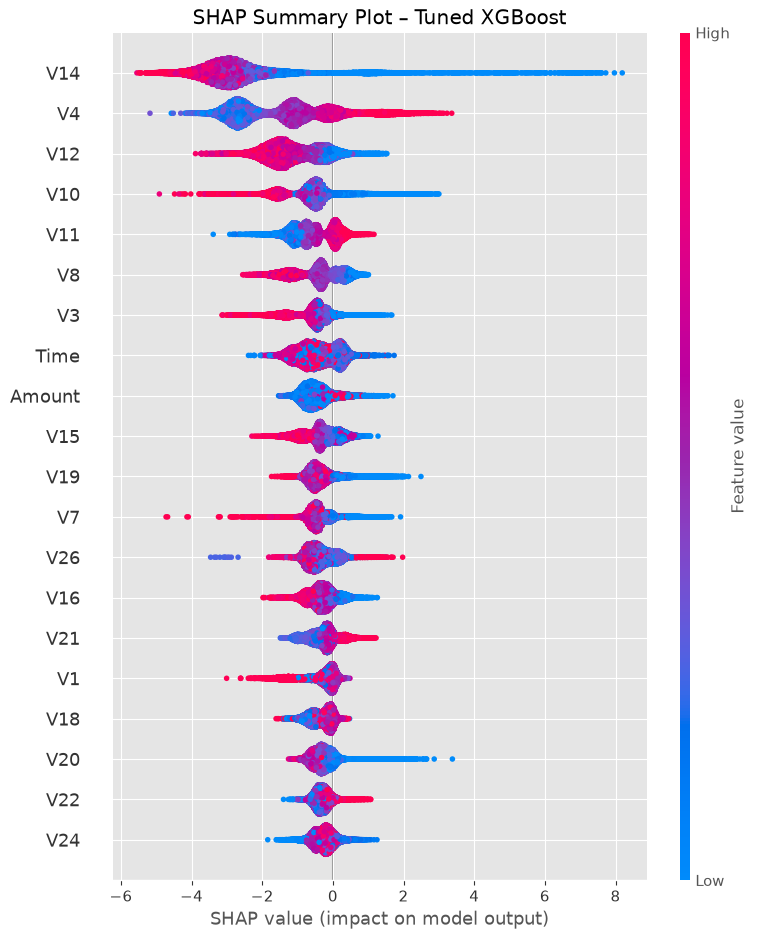

In [122]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))

shap.summary_plot(
    shap_values,
    X_test,
    show=False
)

plt.title("SHAP Summary Plot – Tuned XGBoost")
plt.tight_layout()

plt.savefig(
    "shap_summary_plot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Interpretation

The SHAP summary plot shows the contribution of the 30 input features to the predictions made by the tuned XGBoost model across the test dataset. Features with larger absolute SHAP values have a greater influence on the model's output.

Positive SHAP values indicate that a feature contribution pushed the model toward the fraud class, while negative SHAP values indicate that the contribution pushed the model away from the fraud class. The plot therefore provides a global view of which features most strongly influenced the model's predictions and the direction of their contributions.

SHAP provides model interpretability rather than making an independent prediction. The XGBoost model makes the fraud prediction, while SHAP helps explain the factors that contributed to that prediction.
